## Things to do

* Add attension
* GUI, real-time visualization?
* Normalize only segmented data or just selected?

## Import Libaries

In [1]:
# Classification
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Subset
import sherpa

# Manage datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Manage utils
import os 
from pathlib import Path
import sys
from datetime import datetime
import logging                  # Avoid loggings from GP
from copy import deepcopy       # Used for copy model_state
import antropy as ant

# Feature extraction
from sklearn.preprocessing import StandardScaler

logging.getLogger("GP").setLevel(logging.CRITICAL)
logging.getLogger("GPy").setLevel(logging.CRITICAL)

current_dir = Path().resolve().parent.parent
sys.path.append(str(current_dir))

# Own implementations
from src.utilities.load_and_visualize_data import load_datasets, visualize_EEG

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pin_memory = torch.cuda.is_available()              # Use pin_memory if CUDA is available
print("Pin memory set to:", pin_memory)

Using device: cpu
Pin memory set to: False


## Global variables

In [3]:
EMG_FREQ = 2000
EEG_FREQ = 125
RMS_FREQ = 40

EMG_LOWCUT = 20
EMG_HIGHCUT = 450
EEG_LOWCUT = 0.5
EEG_HIGHCUT = 30

EEG_NUM_CH = 3
EEG_NUM_CH = 16

TRIAL_PERIOD = 9
TRIM_PERIOD = 3

RMS_SAMPLING_WINDOW = 500           # 500 samples - 250 ms                      32 samples - 16 ms                                       
RMS_WINDOW_STEPSIZE = 50            # 50 samples - 25 ms (90 % overlap)         16 samples - 8 ms (50 % overlap)

HAMPEL_WINDOWSIZE = 100
HAMPEL_SIGMA = 2

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

EMG_CONFIG_DICT = {
    'rms_windowsize' : RMS_SAMPLING_WINDOW,
    'rms_stepsize' : RMS_WINDOW_STEPSIZE,
    'hampel_windowsize' : HAMPEL_WINDOWSIZE,
    'hampel_sigma' : HAMPEL_SIGMA,
    'hampel_plot_option' : [False, None],
    'include_EMG' : False
}

REJECT_CONFIG_DICT = {
    'EEG_epoch_rejection_tolerance' : 6,
    'EMG_epoch_rejection_tolerance' : 6,
    'EEG_ch_acceptance' : 0,
    'EMG_ch_acceptance' : 0
}

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Fz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]

EMG_CH_NAMES = [
'Channel 1 : Palmaris longus',
'Channel 2 : Flexor digitorum superficialis',
'Channel 3 : Flexor pollicis longus',
]

## Step 1: Define the LSTM Model

In [4]:
from src.models.classification_pipeline import LSTM
from src.utilities.load_and_visualize_data import load_datasets
from src.utilities.preprocessing import EMG_preprocessing

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Parameter(torch.randn(hidden_dim))           # Learnable vector to scalar score for each time step.

    def forward(self, hidden, encoder_outputs):
        batch_size = encoder_outputs.shape[0]
        seq_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).expand(-1, seq_len, -1)      # (B, H) -> (B, 1, H) -> (B, seq_len, H)

        #=======================================================================================#
        # Step 1)  Feed-Forward Alignment Function: The decoder’s current hidden state 'S_t'    #
        # and each encoder hidden state 'h_i' are combined to compute alignment scores 'e_t,i'. # 
        #=======================================================================================#
        St_hi = torch.cat((hidden, encoder_outputs), dim=2)         # (B, S, 2H)
        energy = torch.tanh(self.attn(St_hi))                            # (B, S, H) - Learns a transformation from the concatenated decoder-hidden + encoder-output to an intermediate "energy" vector
        energy = energy.permute(0, 2, 1)                            # (B, H, S) - Permute for batch matrix multiplication

        #==================================#
        # Step 2) Compute attention scores #
        #==================================#
        v = self.v.repeat(batch_size, 1).unsqueeze(1)                    # (H) -> (B, H) -> (B, 1, H) - Expand v to match batch size and prepare for batch matrix multiplication
        scores = torch.bmm(v, energy)                               # (B, 1, H) x (B, H, S) -> (B, 1, S) - Compute attention scores for each encoder hidden state
        scores = scores.squeeze(1)                                  # (B, S) - Remove the extra dimension
    
        #===================================================#
        # 3) Convert scores to probabilities using softmax, #
        # yielding attention weights 'a_t,i'                #
        # that sum to 1 across all encoder time steps.      #
        #===================================================#
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs)  # (B, 1, S) × (B, S, H) -> (B, 1, H) - Compute the context vector as a weighted sum of encoder hidden states

        return context, weights


## Step 2: Prepare Data

In [6]:
data_dir = Path().resolve().parent / 'experiment/data'


EMG_ins = EMG_preprocessing(fs = EMG_FREQ, bandpass_lowcut = EMG_LOWCUT, bandpass_highcut = EMG_HIGHCUT, trial_period = TRIAL_PERIOD, trim_period = TRIM_PERIOD)
load_ins = load_datasets(base_dir = data_dir)

X_i, _, _ = load_ins.load_EMG_data(subject_name = 'subject_3', finger_name = 'index', EMG_config_dict = EMG_CONFIG_DICT, reject_config_dict = REJECT_CONFIG_DICT, preprocessing_func = EMG_ins.preprocessing_routine)

------------------
Process for EMG data
------------------

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_3\EMG\flex_index_finger_2026-02-11 10-06-49.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_3\EMG\flex_index_finger_2026-02-11 10-14-41.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_3\EMG\flex_index_finger_2026-02-11 10-21-04.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_3\EMG\flex_index_finger_2026-02-11 10-42-48.csv

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [26 71]
Total bad epochs = 2 out of 91


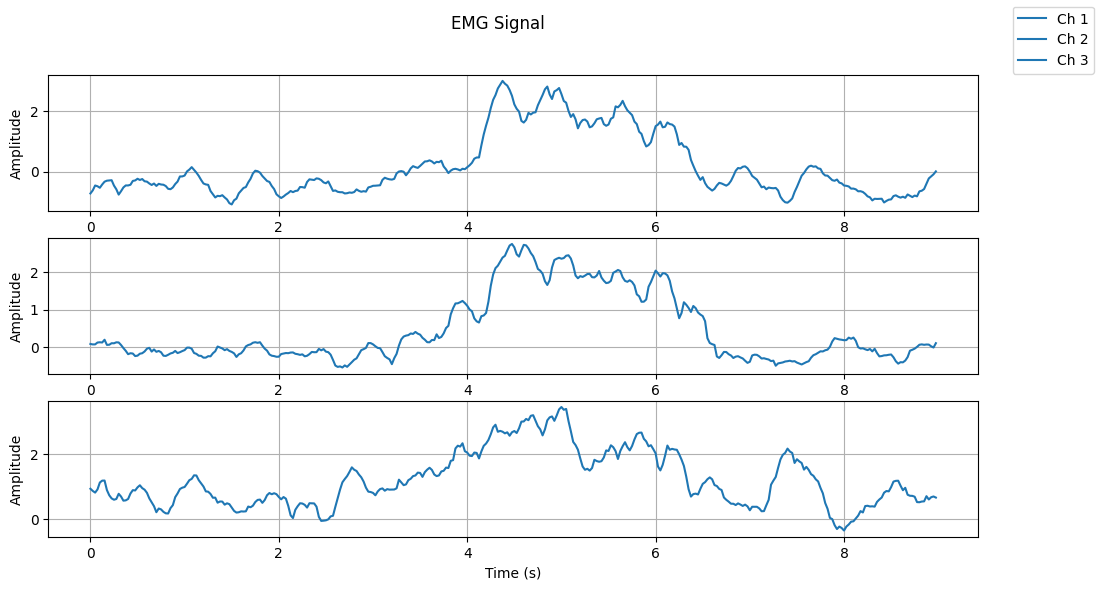

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))

data = X_i[4, 0:RMS_FREQ*9, :]  # First 5 seconds of the first channel
t = np.arange(data.shape[0]) / RMS_FREQ  # Time vector based on the sampling frequency

for i in range(X_i.shape[2]):
    ax = axes[i]
    ax.plot(t, data[:, i], label=f'Ch {i+1}')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid()
fig.suptitle("EMG Signal")
fig.legend()
fig.show()

In [64]:
lstm = LSTM(input_dim=X_i.shape[2], hidden_dim=10, layers=1, dropout=0.0, bidirectional=False, include_attn=False).to(device)
attention = Attention(hidden_dim=10).to(device)

In [65]:
X_i = torch.tensor(X_i, dtype=torch.float32).to(device)

X = X_i[3, :, :].unsqueeze(0)  # (1, seq_len, input_dim)
lstm_out, hidden = lstm(X)  # lstm_out: (1, seq_len, hidden_dim), hidden: (1, hidden_dim)
context, weights = attention(hidden, lstm_out)  # context: (1, 1, hidden_dim), weights: (1, seq_len)

In [66]:
# Move to CPU + numpy
X_np = X.squeeze(0).detach().cpu().numpy()              # (seq_len, input_dim)
lstm_np = lstm_out.squeeze(0).detach().cpu().numpy()    # (seq_len, hidden_dim)
weights_np = weights.squeeze(0).detach().cpu().numpy()  # (seq_len,)

# Optional: time axis (if you know fs)
time = np.arange(X_np.shape[0]) / RMS_FREQ

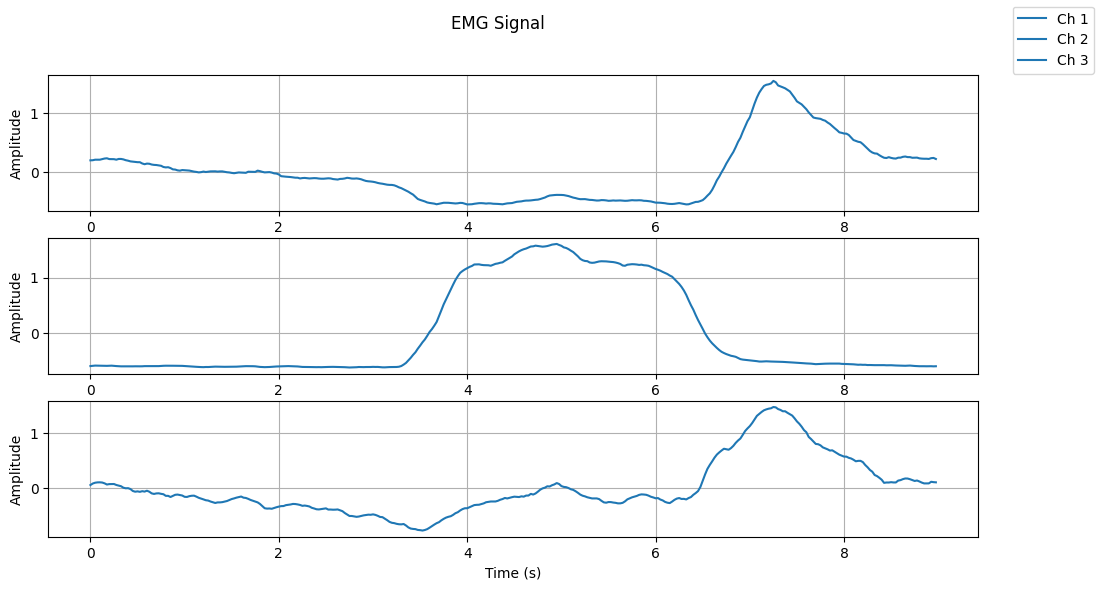

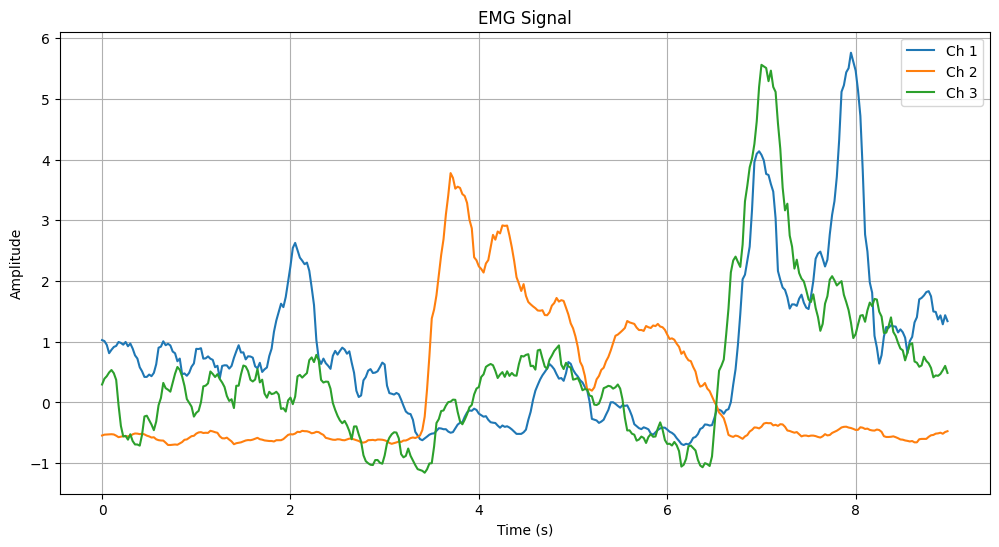

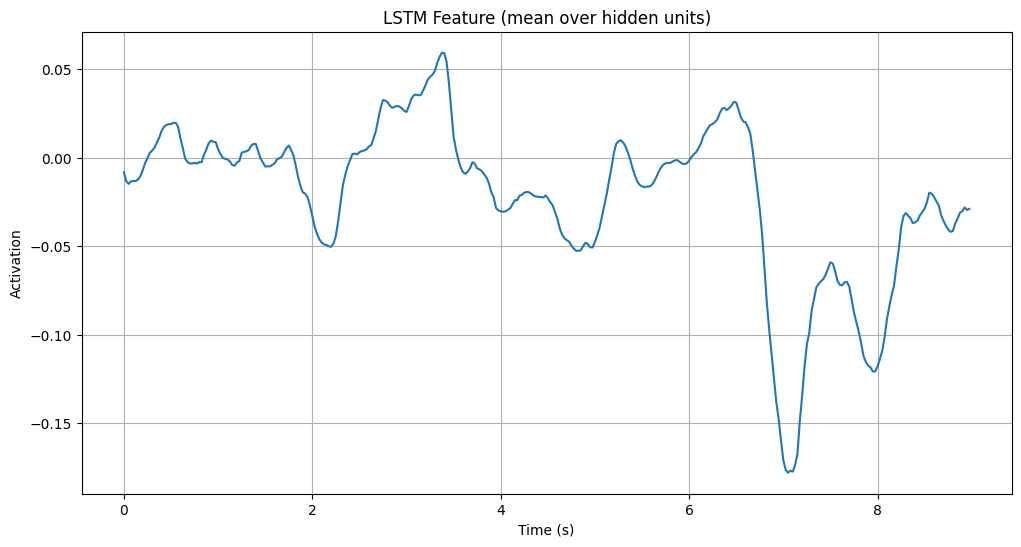

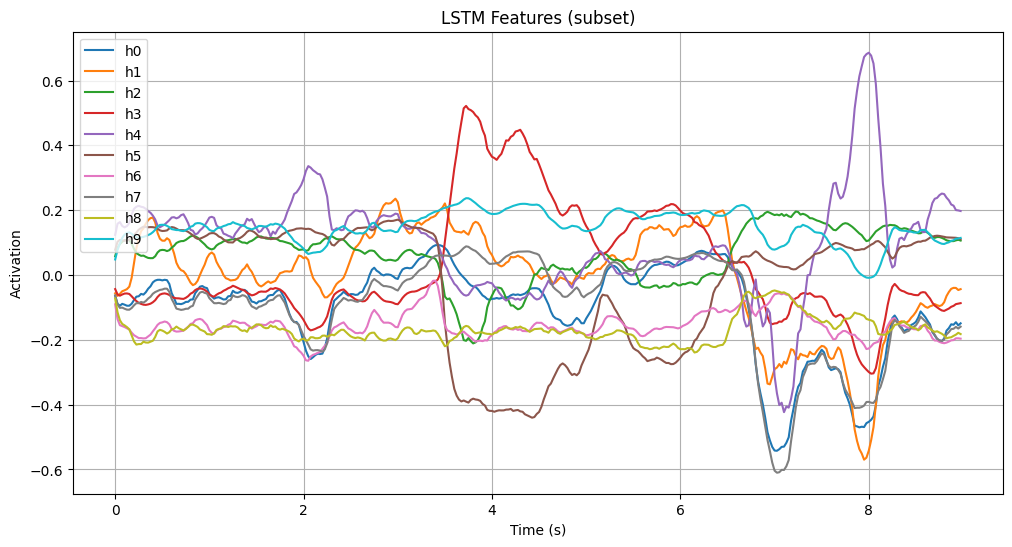

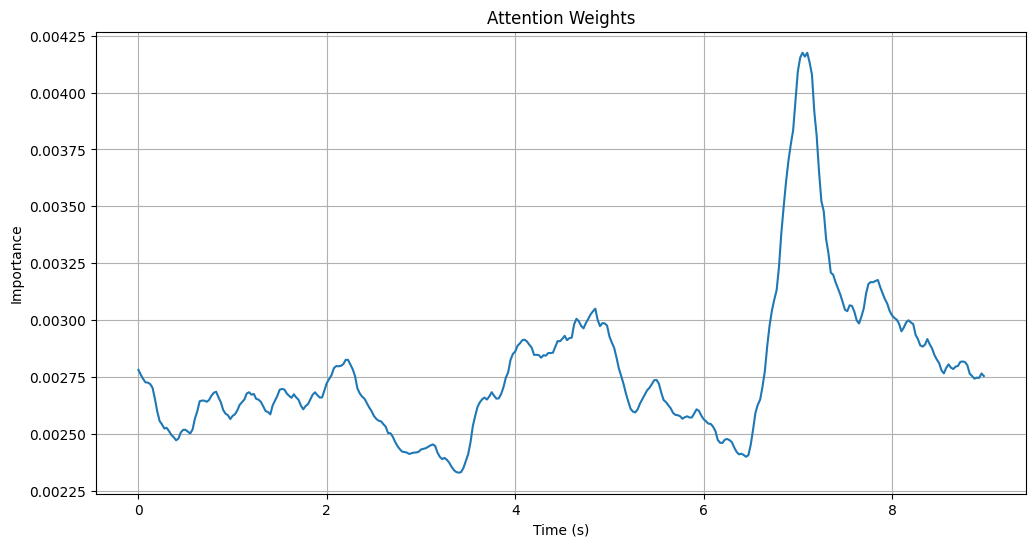

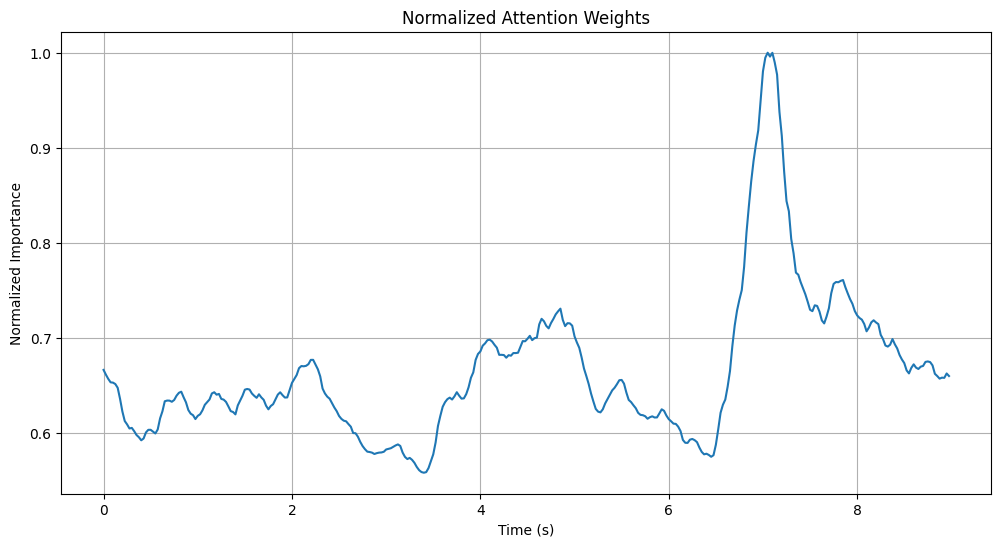

In [68]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))
for i in range(X_i.shape[2]):
    ax = axes[i]
    ax.plot(time, X_i[:, :, i].mean(axis=0), label=f'Ch {i+1}')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid()
fig.suptitle("EMG Signal")
fig.legend()
fig.show()

plt.figure(figsize=(12, 6))
for i in range(X_np.shape[1]):
    plt.plot(time, X_np[:, i], label=f'Ch {i+1}')
plt.title("EMG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

lstm_mean = lstm_np.mean(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(time, lstm_mean)
plt.title("LSTM Feature (mean over hidden units)")
plt.xlabel("Time (s)")
plt.ylabel("Activation")
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
for i in range(10):  # first 5 features
    plt.plot(time, lstm_np[:, i], label=f'h{i}')
plt.legend()
plt.title("LSTM Features (subset)")
plt.xlabel("Time (s)")
plt.ylabel("Activation")
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(time, weights_np)
plt.title("Attention Weights")
plt.xlabel("Time (s)")
plt.ylabel("Importance")
plt.grid()
plt.show()

weights_norm = weights_np / np.max(weights_np)

plt.figure(figsize=(12, 6))
plt.plot(time, weights_norm)
plt.title("Normalized Attention Weights")
plt.xlabel("Time (s)")
plt.ylabel("Normalized Importance")
plt.grid()
plt.show()

## Train simple model

In [21]:
class SimpleModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.lstm = LSTM(input_dim=input_dim, hidden_dim = hidden_dim, layers=1, dropout=0.0, bidirectional=False, include_attn=False)

        self.attention = Attention(hidden_dim)  # your implementation

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, S, input_dim)

        lstm_out, h_n = self.lstm(x)

        hidden = h_n  # (B, H)

        context, weights = self.attention(hidden, lstm_out)  # (B, 1, H)

        context = context.squeeze(1)

        out = self.fc(context)

        return out, weights, lstm_out
    
def _segment_trials(trials : np.ndarray, fs : int) -> tuple[list, list, list]:
    rest     = trials[:, :3*fs, :]
    contract = trials[:, 3*fs:6*fs, :]
    release  = trials[:, 6*fs:, :]

    return rest, contract, release

def _build_split(rest, con, rel) -> tuple[np.ndarray, np.ndarray]:
    
    X = np.concatenate([
        con,
        rel,
        rest
    ])

    y = np.concatenate([
        np.zeros(len(con)),                    # 0 index_contract
        np.ones(len(rel)),                      # 1 index_release
        np.full(len(rest), 2)                  # 2 thumb_contract
    ])

    return X, y

X_rest, X_contract, X_release = _segment_trials(X_i, fs=RMS_FREQ)
X, y = _build_split(X_rest, X_contract, X_release)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

dataset = torch.utils.data.TensorDataset(X, y)
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

model = SimpleModel(input_dim=3, hidden_dim=64, num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Traning loop
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward
        outputs, weights, lstm_out = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 17.6123
Epoch 2, Loss: 14.5391
Epoch 3, Loss: 11.3466
Epoch 4, Loss: 9.6139
Epoch 5, Loss: 8.3571
Epoch 6, Loss: 7.6434
Epoch 7, Loss: 7.1281
Epoch 8, Loss: 4.6828
Epoch 9, Loss: 3.7262
Epoch 10, Loss: 3.4921
Epoch 11, Loss: 4.4902
Epoch 12, Loss: 2.8182
Epoch 13, Loss: 2.8960
Epoch 14, Loss: 2.1333
Epoch 15, Loss: 2.0679
Epoch 16, Loss: 2.6527
Epoch 17, Loss: 1.7481
Epoch 18, Loss: 1.5652
Epoch 19, Loss: 1.5336
Epoch 20, Loss: 1.4993
Epoch 21, Loss: 1.4722
Epoch 22, Loss: 1.3869
Epoch 23, Loss: 1.4133
Epoch 24, Loss: 1.1231
Epoch 25, Loss: 1.1033
Epoch 26, Loss: 0.9782
Epoch 27, Loss: 1.0503
Epoch 28, Loss: 0.9818
Epoch 29, Loss: 1.0285
Epoch 30, Loss: 1.1566


Label at SELECT_SAMPLE: 0
Shape of all_lstm_outs: (10, 120, 64)
Shape of all_weights: (10, 120)
Shape of all_samples: (10, 120, 3)
Shape of all_hn: (10, 64)


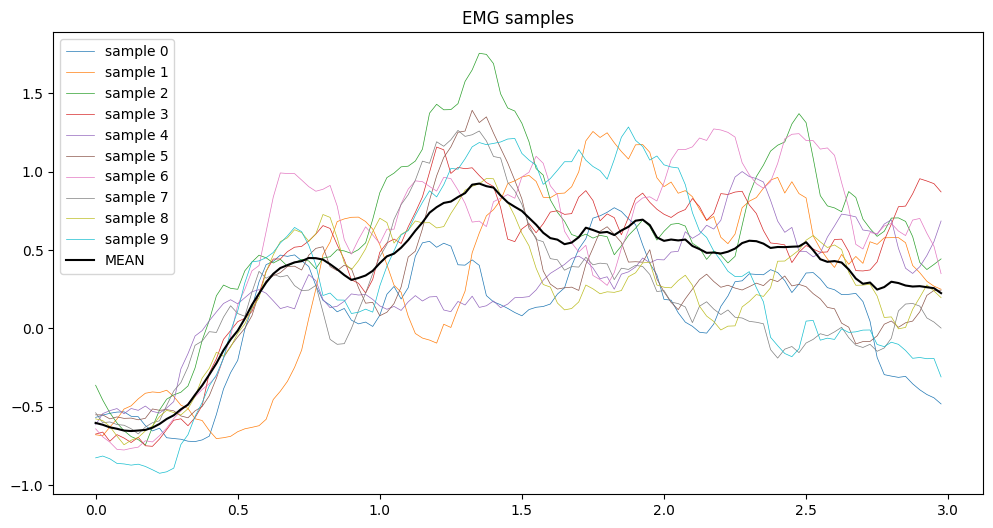

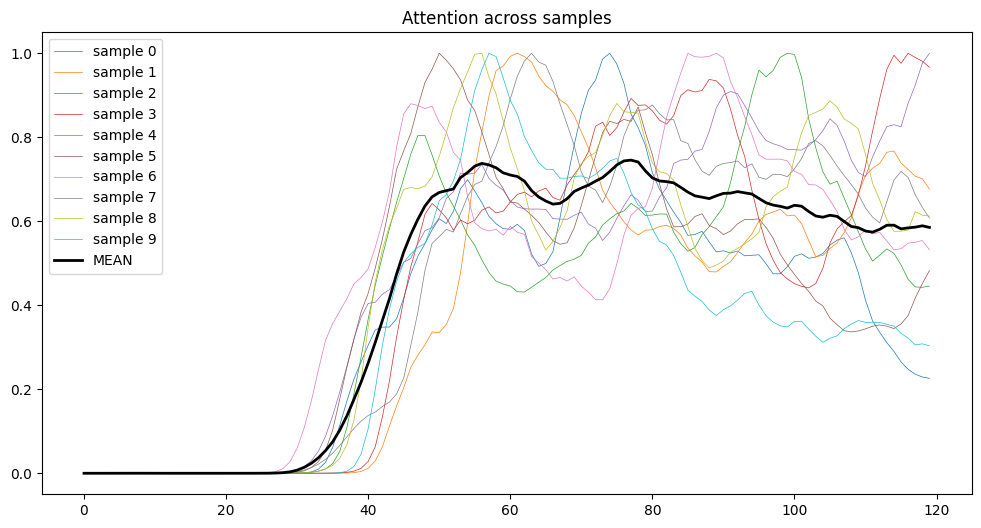

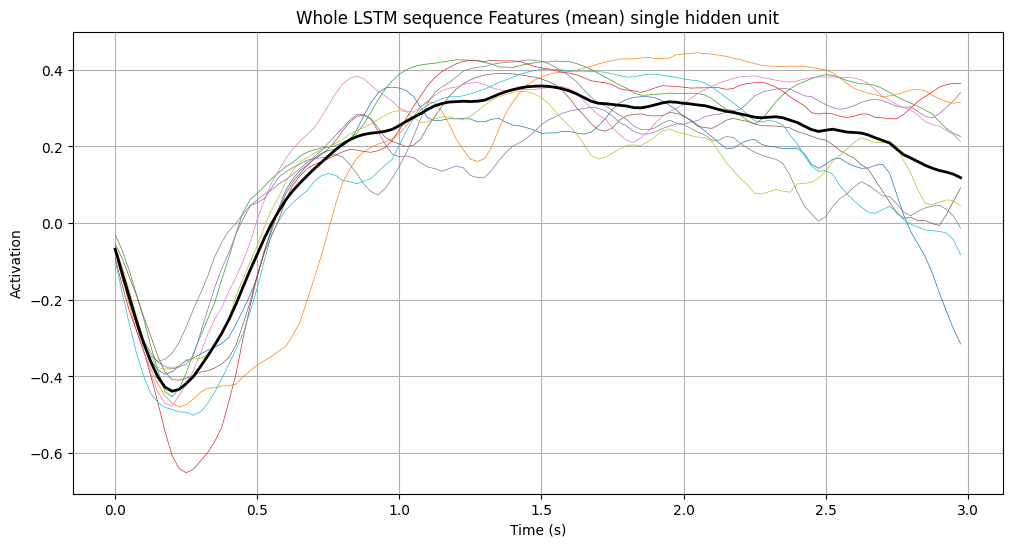

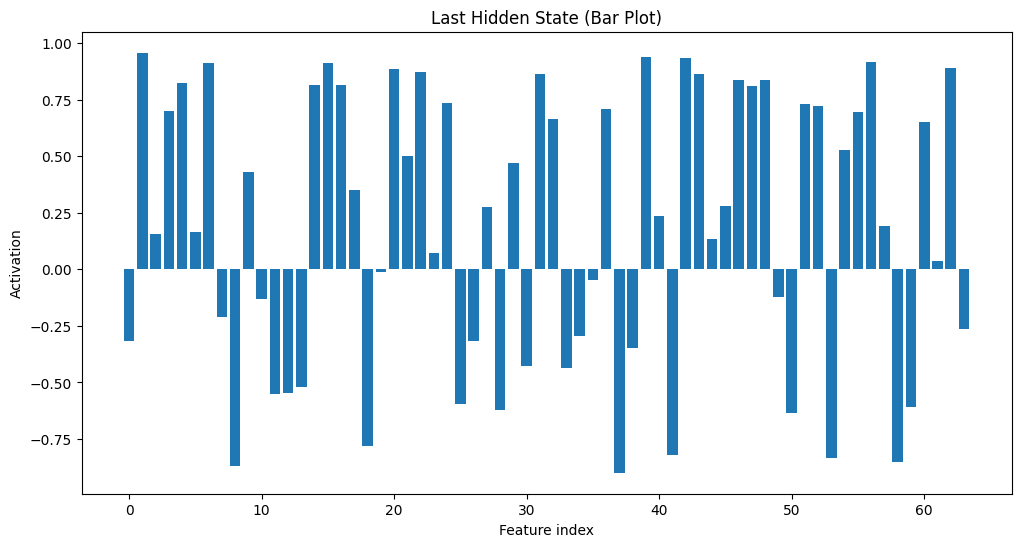

In [78]:
model.eval()

# Index 0 to 60 (first 3 seconds of the first trial) is contract
# Index 100 to 150 (3 to 6 seconds of the first trial) is release
# Index 200 to 250 (6 to 9 seconds of the first trial) is rest

SELECT_SAMPLE = 30
print(f'Label at SELECT_SAMPLE: {y[SELECT_SAMPLE].item()}')

all_weights = []
all_lstm_outs = []
all_hn = []
all_samples = []


with torch.no_grad():

    for i in range(10):
        
        sample = X[SELECT_SAMPLE+i].unsqueeze(0).to(device)

        output, weights, lstm_out = model(sample)

        weights_np = weights.squeeze(0).detach().numpy()
        lstm_out_np = lstm_out.squeeze(0).detach().numpy()
        hn = lstm_out[:, -1, :].squeeze(0).detach().numpy()

        weights_norm = weights_np / np.max(weights_np)

        all_weights.append(weights_norm)
        all_lstm_outs.append(lstm_out_np)
        all_hn.append(hn)
        all_samples.append(sample.squeeze(0).detach().cpu().numpy())

all_weights = np.array(all_weights)  # (num_samples, seq_len)
all_lstm_outs = np.array(all_lstm_outs)  # (num_samples, seq_len, hidden_dim)
all_samples = np.array(all_samples)  # (num_samples, seq_len, input_dim)
all_hn = np.array(all_hn)  # (num_samples, hidden_dim)

print('Shape of all_lstm_outs:', all_lstm_outs.shape)
print('Shape of all_weights:', all_weights.shape)
print('Shape of all_samples:', all_samples.shape)
print('Shape of all_hn:', all_hn.shape)


#======================#
# Plotting EMG samples #
#======================#
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(np.arange(all_samples.shape[1]) / RMS_FREQ, all_samples[i, :, 1], label=f"sample {i}", linewidth=0.5)

plt.plot(np.arange(all_samples.shape[1]) / RMS_FREQ, all_samples[:, :, 1].mean(axis=0), label="MEAN", color = 'black')

plt.legend()
plt.title("EMG samples")
plt.show()

#============================#
# Plotting Attention Weights #
#============================#
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(all_weights[i], label=f"sample {i}", linewidth=0.5)

plt.plot(all_weights.mean(axis=0), label="MEAN", color='black', linewidth=2)

plt.legend()
plt.title("Attention across samples")
plt.show()

#===============================================#
# Plotting LSTM mean Features from all sequence #
#===============================================#
lstm_mean = all_lstm_outs.mean(axis=0)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(time, all_lstm_outs[i, :, 0], label=f"sample {i}", linewidth=0.5)  
plt.plot(time, lstm_mean[:, 0], label="MEAN", color='black', linewidth=2)
plt.title("Whole LSTM sequence Features (mean) single hidden unit")
plt.xlabel("Time (s)")
plt.ylabel("Activation")
plt.grid()
plt.show()

#==================================#
# Plotting LSTM last hidden states #
#==================================#
hn_mean = all_hn.mean(axis=0)

plt.figure(figsize=(12, 6))
plt.bar(np.arange(all_hn.shape[1]), all_hn[0, :])
plt.title("Last Hidden State (Bar Plot)")
plt.xlabel("Feature index")
plt.ylabel("Activation")
plt.show()

In [20]:
sample.shape, y[SELECT_SAMPLE]

(torch.Size([1, 120, 3]), tensor(1))

In [16]:
X_np = sample.squeeze(0).cpu().numpy()         # (seq_len, input_dim)
weights_np = weights.squeeze(0).cpu().numpy() # (seq_len,)
lstm_np = lstm_out.squeeze(0).cpu().numpy()   # (seq_len, hidden_dim)
X_np.shape, weights_np.shape, lstm_np.shape

((120, 3), (120,), (120, 64))

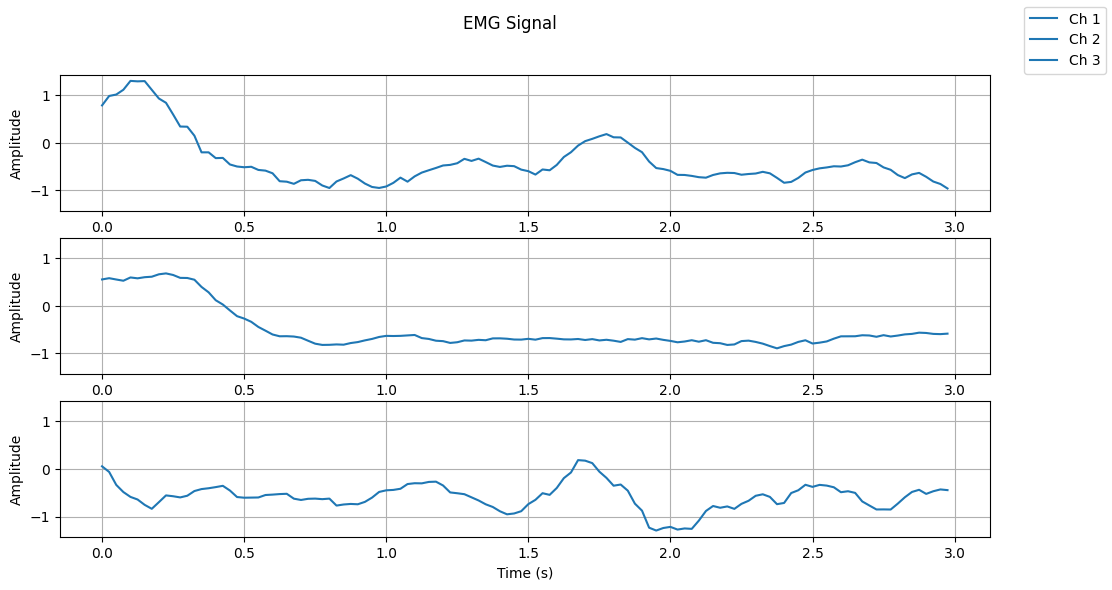

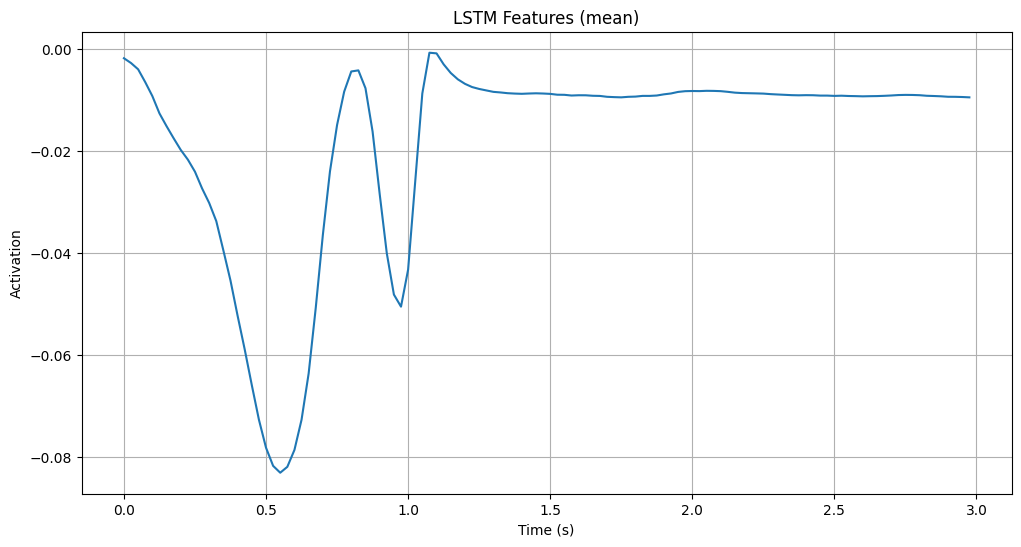

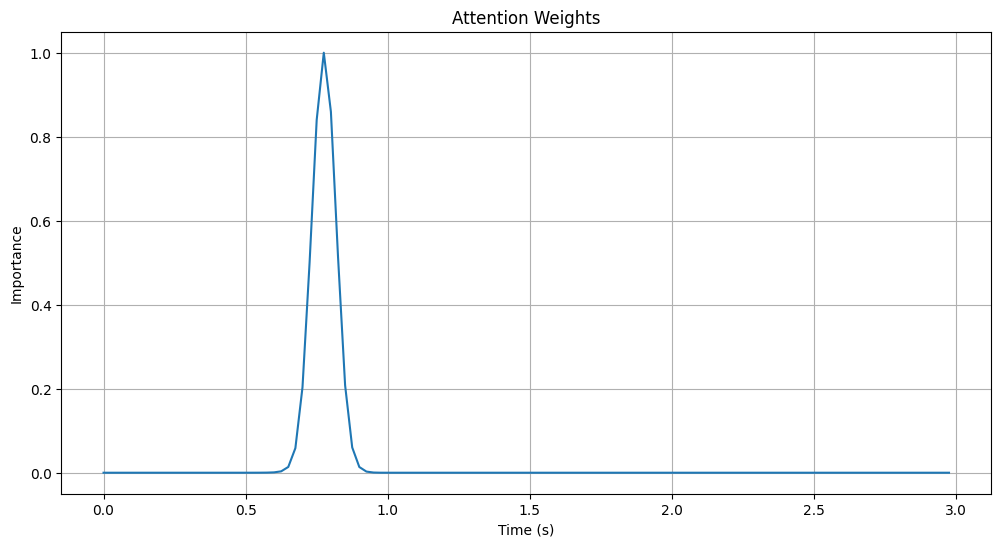

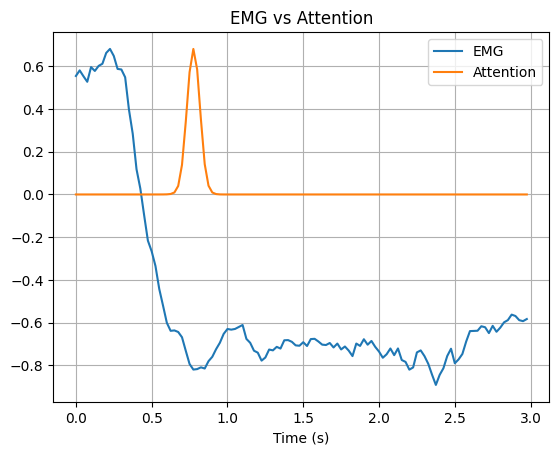

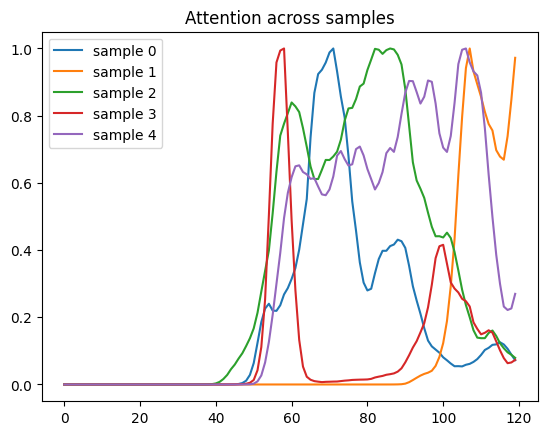

In [ ]:
time = np.arange(X_np.shape[0]) / RMS_FREQ

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharey=True)
for i in range(X_np.shape[1]):
    ax = axes[i]
    ax.plot(time, X_np[:, i], label=f'Ch {i+1}')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid()
fig.suptitle("EMG Signal")
fig.legend()
fig.show()

weights_norm = weights_np / np.max(weights_np)

plt.figure(figsize=(12, 6))
plt.plot(time, weights_norm)
plt.title("Attention Weights")
plt.xlabel("Time (s)")
plt.ylabel("Importance")
plt.grid()
plt.show()

plt.figure()

### BCI2a Dataset

In [15]:
from src.models.classification_BCI2a import Manage2Split

split_ins = Manage2Split(seed = 42)

dataset, reject, raw, epoch_overview = load_BCI2a_dataset(subject_id = 'subject_1')

LH_Train = dataset['left_hand_train.csv']
LH_Test = dataset['left_hand_test.csv']
LH_epoch_Train = epoch_overview['left_hand_train.csv']
LH_epoch_Test = epoch_overview['left_hand_test.csv']

RH_Train = dataset['right_hand_train.csv']
RH_Test = dataset['right_hand_test.csv']
RH_epoch_Train = epoch_overview['right_hand_train.csv']
RH_epoch_Test = epoch_overview['right_hand_test.csv']


# Concat of class 1 and class 2
X_train_val_concat, y_train_val_concat = split_ins.build_split(epoch_class1 = LH_Train, epoch_class2 = RH_Train)
X_test_concat, y_test_concat = split_ins.build_split(epoch_class1 = LH_Test, epoch_class2 = RH_Test)


-----------------------------------
Subject_subject_1 - class : left_hand_train.csv
Num epochs 68.0 EEG epoch shape: (68, 1001, 22)

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [10 15 20 45 55]
Total bad epochs = 5 out of 68

-----------------------------------
Subject_subject_1 - class : right_hand_train.csv
Num epochs 72.0 EEG epoch shape: (72, 1001, 22)

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [13 40 58 70]
Total bad epochs = 4 out of 72

-----------------------------------
Subject_subject_1 - class : left_hand_test.csv
Num epochs 69.0 EEG epoch shape: (69, 1001, 22)

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [16 17 33]
Total bad epochs = 3 out of 69

-----------------------------------
Subject_subject_1 - class : right_hand_test.csv
Num epochs 72.0 EEG epoch shape: (72, 1001, 22)

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [ 3  4 17 44 56]
Total bad epochs = 5 out of 72

----

## Feature Extraction

### Functions

In [10]:
import scipy.stats as stats
from typing import Callable

class Feature_Extraction():
    def __init__(self, fs = 250, window_size = 150, step_size = 75):
        self.fs = fs
        self.window_size = window_size
        self.step_size = step_size

    def window_epoch_equal_periods(self, data_epoch):
        """
        Only used for OpenBCI

        data_epoch: (1125, channels)
        returns:
            (num_windows_total, window_size, channels)
        """

        PERIOD = 375
        windows_all = []

        for i in range(3):  # rest, contract, release
            start = i * PERIOD
            end   = start + PERIOD

            segment = data_epoch[start:end]

            w = self.centered_sliding_windows(
                segment,
                self.window_size,
                self.step_size
            )

            windows_all.append(w)

        return np.concatenate(windows_all, axis=0)

    def centered_sliding_windows(self, data):
        """
        data: (samples, channels)

        Returns:
            windows: (n_windows, window_size, channels)
            centers: center sample indices
        """
        from numpy.lib.stride_tricks import sliding_window_view
        half = self.window_size // 2

        # symmetric padding
        padded = np.pad(                # Mirror the edges by half of the window_size. So array of [0 1 2 1 0] with window_size 3 becombes after padding [1 0 1 2 1 0 1]
            data,
            ((half, half), (0, 0)),
            mode='reflect'
        )
        
        windows = sliding_window_view(  # Slide over data with window size. The example from before with stepsize of 1: [1 0 1] -> [0 1 2] -> [1 2 1] -> [2 1 0] - > [1 0 1]
            padded,
            window_shape = self.window_size,
            axis=0
        )

        windows = windows[::self.step_size]


        return windows          # Shape (n_windows, window_size, channels)

    def extract_statistical_features(self, signal):
        mean = np.mean(signal)
        median = np.median(signal)
        std_dev = np.std(signal)
        variance = np.var(signal)
        skewness = stats.skew(signal)
        kurtosis = stats.kurtosis(signal)
        range_val = np.ptp(signal)
        abs_area = np.sum(np.abs(signal))
        
        features = {
            'Mean': mean,
            'Median': median,
            'Standard Deviation': std_dev,
            'Variance': variance,
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'Range': range_val,
            'Absolute Area' : abs_area
        }
        
        return features

    def extract_time_domain_features(self, signal):
        rms = np.sqrt(np.mean(signal**2))
        zero_crossings = ((signal[:-1] * signal[1:]) < 0).sum()
        autocorrelation = np.correlate(signal, signal, mode='full')[len(signal)-1]
        mean_abs_dev = np.mean(np.abs(signal - np.mean(signal)))
        max_val = np.max(signal)
        min_val = np.min(signal)
        signal_energy = np.sum(signal**2)
        
        features = {
            'RMS': rms,
            'Zero Crossings': zero_crossings,
            'Autocorrelation': autocorrelation,
            'Mean Absolute Deviation': mean_abs_dev,
            'Max Value': max_val,
            'Min Value': min_val,
            'Signal Energy': signal_energy
        }
        
        return features

    def extract_frequency_domain_features(self, signal):
        from scipy.signal import welch
        freqs, psd = welch(signal, self.fs)
        # dominant_freq = freqs[np.argmax(psd)]
        #total_power = np.sum(psd)
        band_power_delta = np.sum(psd[(freqs >= 0.5) & (freqs <= 4)])
        band_power_theta = np.sum(psd[(freqs >= 4) & (freqs <= 8)])
        band_power_alpha = np.sum(psd[(freqs >= 8) & (freqs <= 12)])
        band_power_beta = np.sum(psd[(freqs >= 12) & (freqs <= 30)])
        # mean_freq = np.mean(freqs)
        # median_freq = np.median(freqs)
        # peak_freq = freqs[np.argmax(psd)]
        # freq_variance = np.var(freqs)
        
        features = {
            'Band Power Delta' : band_power_delta,
            'Band Power Theta' : band_power_theta,
            'Band Power Alpha' : band_power_alpha, 
            'Band Power Beta' : band_power_beta
        }
        
        '''
        features = {
            'Dominant Frequency': dominant_freq,
            'Total Power': total_power,
            'Band Power (0.5-40 Hz)': band_power,
            'Mean Frequency': mean_freq,
            'Median Frequency': median_freq,
            'Peak Frequency': peak_freq,
            'Frequency Variance': freq_variance
        }
        '''
        return features

    def extract_entropy_features(self, signal):
        sample_entropy = ant.sample_entropy(signal)
        spectral_entropy = ant.spectral_entropy(signal, sf = self.fs, method='welch')
        perm_entropy = ant.perm_entropy(signal, normalize=True)
        svd_entropy = ant.svd_entropy(signal, order=3, delay=1)
        app_entropy = ant.app_entropy(signal)
        
        features = {
            'Sample Entropy': sample_entropy,
            'Spectral Entropy': spectral_entropy,
            'Permutation Entropy': perm_entropy,
            'SVD Entropy': svd_entropy,
            'Approximate Entropy': app_entropy
        }
        
        return features

    def extract_features_from_windows(self, X_epoch, feature_func_dict : Callable):

        num_epochs, num_windows, n_channels, _ = X_epoch.shape

        all_rows = []
        track_info = []

        for epo in range(num_epochs):
            for win in range(num_windows):

                row_features = {}
                row_info = {}

                for ch in range(n_channels):

                    signal = X_epoch[epo, win, ch, :]

                    for func_name, feature_func in feature_func_dict.items():
                        
                        feats = feature_func(signal)

                        # rename features per channel
                        for feat_name, value in feats.items():
                            col_name = f'ch{ch}_{func_name}_{feat_name}'
                            row_features[col_name] = value

                # optional tracking info
                row_info['epoch'] = epo
                row_info['window'] = win

                all_rows.append(row_features)
                track_info.append(row_info)

        df = pd.DataFrame(all_rows)
        df_info = pd.DataFrame(track_info)

        return df, df_info                  # df shape: (num_epochs * num_windows, num_features)

    def create_window_labels(self, df, windows_per_period):
        '''
        Only used for OpenBCI
        '''
        Y = np.zeros(len(df), dtype=int)
        Wpp = windows_per_period

        Y[df['window'] < Wpp] = 0          # Rest
        Y[(df['window'] >= Wpp) &
        (df['window'] < Wpp*2)] = 1        # Contract
        Y[df['window'] >= Wpp*2] = 2         # Release

        return Y

    def df_to_lstm(self, normalized_df, num_epochs, num_windows):

        feature_cols = [
            c for c in normalized_df.columns
        ]

        X = normalized_df[feature_cols].values

        X = X.reshape(num_epochs,
                    num_windows,
                    len(feature_cols))

        return X


In [12]:
from sklearn.preprocessing import StandardScaler
window_size = 150           # 150 - Openbci
step_size = 75              # 75 - Openbci

feat_ins = Feature_Extraction(fs = 250, window_size = window_size, step_size = step_size)

# Concatinate classes with shape (epochs, samples, channels)
EEG_slide_train_val = np.array([                        
    feat_ins.centered_sliding_windows(epo)
    for epo in X_train_val_concat
])  # Return (Epoch, windows, channel, window_size)

EEG_slide_test = np.array([                        
    feat_ins.centered_sliding_windows(epo)
    for epo in X_test_concat
])  # Return (Epoch, windows, channel, window_size)

feature_func_dict = {
    'stat' : feat_ins.extract_statistical_features,
    'time domain' : feat_ins.extract_time_domain_features,
    'freq domain' : feat_ins.extract_frequency_domain_features,           # NOTE: Set frequency in function
    'entropy' : feat_ins.extract_entropy_features                         # NOTE: Set frequency in function

}

EEG_train_val_df, _ = feat_ins.extract_features_from_windows(X_epoch = EEG_slide_train_val,
                                                            feature_func_dict = feature_func_dict
                                                            ) # (num_epochs * num_windows, num_features)

EEG_test_df, _ = feat_ins.extract_features_from_windows(X_epoch = EEG_slide_test,
                                                        feature_func_dict = feature_func_dict
                                                        ) # (num_epochs * num_windows, num_features)

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to normalize the data
EEG_train_val_norm = scaler.fit_transform(EEG_train_val_df)
EEG_test_norm = scaler.fit_transform(EEG_test_df)

# Convert the result back into a DataFrame
EEG_train_val_norm_df = pd.DataFrame(EEG_train_val_norm, columns = EEG_train_val_df.columns)
EEG_test_norm_df = pd.DataFrame(EEG_test_norm, columns = EEG_test_df.columns)

''' Used for OPENBCI dataset
#=============#
# For OpenBCI #
#=============#
# Y = create_window_labels(info_df, windows_per_period = 6)
# EEG_features = df_to_lstm(normalized_df = ornmalized_df, num_epochs = 84, num_windows = 18)
# print(EEG_features.shape)       # (epochs, windows, features)
'''


' Used for OPENBCI dataset\n#=============#\n# For OpenBCI #\n#=============#\n# Y = create_window_labels(info_df, windows_per_period = 6)\n# EEG_features = df_to_lstm(normalized_df = ornmalized_df, num_epochs = 84, num_windows = 18)\n# print(EEG_features.shape)       # (epochs, windows, features)\n'

In [45]:
T_epochs, T_windows, T_chs, T_samples = EEG_slide_train_val.shape
TE_epochs, TE_windows, TE_chs, TE_samples = EEG_slide_test.shape

In [34]:
train_val_labels = np.concatenate([np.zeros(LH_epoch_Train*T_windows), np.ones(RH_epoch_Train*T_windows)])

normalized_labeled_df = EEG_train_val_df.copy()
normalized_labeled_df['class'] = train_val_labels

significant_features = []

for feature in EEG_train_val_norm_df.columns:
    class_0 = EEG_train_val_norm_df[feature][normalized_labeled_df['class'] == 0]
    class_1 = EEG_train_val_norm_df[feature][normalized_labeled_df['class'] == 1]
    
    stat, p = stats.kruskal(class_0, class_1)

    if p < 0.05:
        significant_features.append(feature)

In [51]:
significant_features
X_train = EEG_train_val_norm_df[significant_features]           # Extract those features which are significant
X_test   = EEG_test_norm_df[significant_features]

X_train = feat_ins.df_to_lstm(X_train, T_epochs, T_windows)
X_test = feat_ins.df_to_lstm(X_test, TE_epochs, TE_windows)
print(X_train.shape)
train_rng_indices, val_rng_indices = split_ins.split_trials(T_epochs)
test_rng_indices = split_ins.shuffle_BCI2a_test(num_epochs = TE_epochs)

(131, 14, 148)
Train split indicies (104,)
 Valdiation split indicies (27,)



## CHECK: Is my data significant

### Functions

In [46]:
def compute_pca(X, y):
    '''
    Give the concat data
    '''
    from sklearn.decomposition import PCA

    X_flat = X.reshape(X.shape[0], -1)   # epochs × features
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_flat)

    plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10')
    plt.title("PCA class separation")
    plt.show()

def compute_tSNE(X, y):
    from sklearn.manifold import TSNE

    X_flat = X.reshape(X.shape[0], -1)   # epochs × features
    tsne = TSNE(n_components=2, random_state=42, perplexity=50)
    X_tsne = tsne.fit_transform(X_flat)

    plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='tab10')
    plt.title("t-SNE class separation")
    plt.show()

def compute_mean_anova(X, y, ch = 0):
    from scipy.stats import f_oneway

    F, p = f_oneway(
        X[y==0,:,ch].mean(axis=1),
        X[y==1,:,ch].mean(axis=1),
        # X[y==2,:,ch].mean(axis=1)
    )

    print(p)

def compute_cohens_d(a, b):
    return (a.mean()-b.mean()) / \
           np.sqrt((a.var()+b.var())/2)

def train_simple_classifier(X, y):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score

    X_flat = X.reshape(X.shape[0], -1)   # epochs × features

    clf = LogisticRegression(max_iter=1000)
    acc = cross_val_score(clf, X_flat, y, cv=5)

    print(acc.mean())

In [47]:
y_class0 = np.zeros(63*14)          # Epochs * window
y_class1 = np.ones(68*14)

y_classes = np.concatenate([y_class0, y_class1])

148
ch0_freq domain_Band Power Theta 0.010636294613041235
ch0_entropy_Approximate Entropy 0.033009430046296154
ch1_entropy_Sample Entropy 0.04231163088142391
ch1_entropy_Approximate Entropy 0.02881719954857977
ch3_entropy_SVD Entropy 0.026668460453429663
ch4_time domain_Min Value 0.03457852473132279
ch5_time domain_Min Value 0.02850865529209604
ch6_stat_Range 0.0083374772877433
ch6_time domain_Max Value 0.016281345301973397
ch6_time domain_Min Value 0.02144826537799733
ch7_stat_Median 0.04866348990594208
ch7_stat_Standard Deviation 0.0039669414790285285
ch7_stat_Variance 0.0039669414790285285
ch7_stat_Kurtosis 0.021826152976447584
ch7_stat_Range 0.00022313122795574296
ch7_stat_Absolute Area 0.012853716527642431
ch7_time domain_RMS 0.003802415452049904
ch7_time domain_Autocorrelation 0.003802415452049904
ch7_time domain_Mean Absolute Deviation 0.01280913371758894
ch7_time domain_Max Value 0.00392382976287901
ch7_time domain_Min Value 0.00016498986462396974
ch7_time domain_Signal Energy 

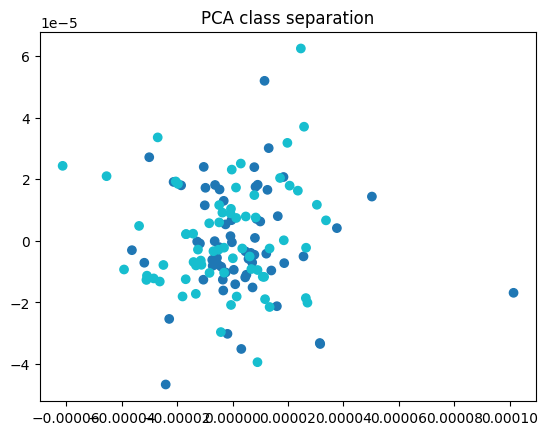

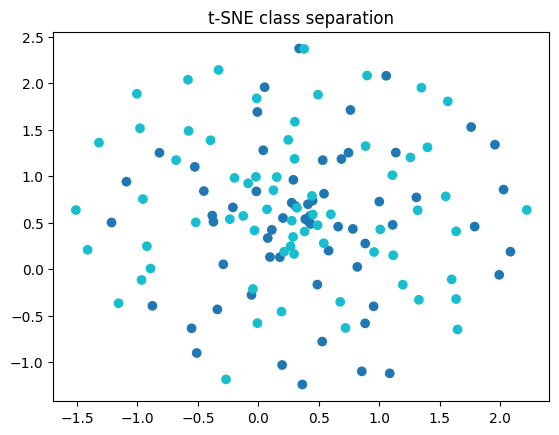

ANOVA
0.5573608878987901
0.8224104104345417
0.9558165168140025
0.7790642339919237
0.7224350142569675
0.5881343778802957
0.9107500448311562
0.7677779347051877
0.8972930149642455
0.987725361052406
0.9521023454682991
0.7794873760807024
0.8559171400396925
0.8739243272460286
0.8561311773347119
0.7877174085385207
0.5468935841249192
0.6486761874374252
0.8317203111820396
0.623736911499942
0.578053087705019
0.676688221111669
cohens_d
Channel 0 Cohen's d: 0.104
Channel 1 Cohen's d: 0.040
Channel 2 Cohen's d: 0.010
Channel 3 Cohen's d: 0.050
Channel 4 Cohen's d: 0.063
Channel 5 Cohen's d: 0.095
Channel 6 Cohen's d: 0.020
Channel 7 Cohen's d: 0.052
Channel 8 Cohen's d: -0.023
Channel 9 Cohen's d: 0.003
Channel 10 Cohen's d: -0.011
Channel 11 Cohen's d: 0.049
Channel 12 Cohen's d: 0.032
Channel 13 Cohen's d: 0.028
Channel 14 Cohen's d: -0.032
Channel 15 Cohen's d: -0.048
Channel 16 Cohen's d: -0.107
Channel 17 Cohen's d: -0.081
Channel 18 Cohen's d: -0.037
Channel 19 Cohen's d: -0.087
Channel 20 Co

In [ ]:
X_sel = X_EEG
labels_sel = labels_EEG


normalized_labeled_df = normalized_df.copy()
normalized_labeled_df['class'] = y_classes

kruskal_results = {}
for feature in normalized_labeled_df.columns:
    if feature == 'class':
        continue
    class_0 = normalized_labeled_df[feature][normalized_labeled_df['class'] == 0]
    class_1 = normalized_labeled_df[feature][normalized_labeled_df['class'] == 1]
    # class_2 = normalized_labeled_df[feature][normalized_labeled_df['class'] == 2]
    kruskal_results[feature] = stats.kruskal(class_0, class_1).pvalue

kruskal_results_df = pd.DataFrame(list(kruskal_results.items()), columns=['Feature', 'P-value'])

print(len(kruskal_results_df[kruskal_results_df['P-value'] < 0.05]))
kruskal_results_df[kruskal_results_df['P-value'] < 0.05]

significant_features = 0
non_significant_features = 0
normalized_significant_features = {}
for feature, value in kruskal_results.items():
    if value < 0.05:
        print(feature, value)
        normalized_significant_features[feature] = normalized_df[feature]
        significant_features += 1
    else:
        non_significant_features += 1

normalized_significant_features = pd.DataFrame(normalized_significant_features)

print('Significant count :', significant_features)
print('Non significant count :', non_significant_features)
        
# Perform PCA
compute_pca(X_sel[:, :, 0], labels_sel)

# Perform t-SNE
compute_tSNE(X_sel, labels_sel)

# Perform ANOVA - p < 0.05
print('ANOVA')
[compute_mean_anova(X_sel, labels_sel, ch=c) for c in range(X_sel.shape[2])]

# Perform Cohen's d
print('cohens_d')
for c in range(X_sel.shape[2]):
    d = compute_cohens_d(X_sel[labels_sel==0,:,c].mean(axis=1), X_sel[labels_sel==1,:,c].mean(axis=1))
    print(f"Channel {c} Cohen's d: {d:.3f}")

train_simple_classifier(X_sel, labels_sel)

In [61]:
X_EEG_features = df_to_lstm(normalized_significant_features, num_epochs = 131, num_windows = 14)

y_class0 = np.zeros(63)          # Epochs * window
y_class1 = np.ones(68)
y_classes = np.concatenate([y_class0, y_class1])

X_EEG_features.shape, y_classes            # (epochs, lstm_seq, features)

((131, 14, 148),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

## Plot functions

In [105]:
def plot_emg_mean_epoch_single_channels(emg_epoch_mean, rms_epoch_mean, ch1 = 0, ch2 = 1, key1 = None, key2 = None):

    fig, axs = plt.subplots(
    1, 2,
    figsize=(18, 6),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    #print('Channel Name :', EMG_CH_NAMES[emg_ch], 'and', EMG_CH_NAMES[rms_ch])

    emg1 = np.array(emg_epoch_mean[key1][:, ch1])
    rms1 = np.array(rms_epoch_mean[key1][:, ch1])

    emg2 = np.array(emg_epoch_mean[key2][:, ch2])
    rms2 = np.array(rms_epoch_mean[key2][:, ch2])

    time = np.arange(emg1.shape[0]) / EMG_FREQ
    RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
    win_time = (np.arange(rms1.shape[0]) * (16) + 16) / EMG_FREQ


    axs[0].plot(time, emg1, color='royalblue', linewidth=1.0, label = 'Index finger')
    axs[0].plot(win_time, rms1, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    #axs[0].set_xlim([0, 9])
    #axs[0].set_ylim([-2, 2])
    #axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EMG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc = 'lower left')

    axs[0].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[0].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

    axs[1].plot(time, emg2, color='royalblue', linewidth=1.0, label='Thumb')
    axs[1].plot(win_time, rms2, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    #axs[1].set_xlim([0, 9])
    #axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc = 'lower left')

    axs[1].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[1].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

def plot_EEG_across_channels(EEG_epoch, freq = 125, sel_ch = None):
    if EEG_epoch.ndim == 3:
        data = EEG_epoch.reshape(-1, 16).copy()
        print(data.shape)
    if EEG_epoch.ndim == 2:
        data = EEG_epoch.copy()

    n_samples, n_channels = data.shape
    time = np.arange(n_samples) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(data)
    y_max = np.max(data)
    print(f'Y-axis limits: {y_min} to {y_max}')

    if sel_ch is None:
        sel_ch = list(range(n_channels))

    fig, axs = plt.subplots(8, 2, figsize=(30, 45))

    for ch in range(n_channels):
        row = ch // 2
        col = ch % 2
        axs[row, col].plot(time, data[:, ch])
        
        axs[row, col].set_title(f'Channel: {EEG_CH_NAMES[sel_ch[ch]]}')
        axs[row, col].set_xlabel('Time (s)')
        axs[row, col].set_ylabel('Amplitude (a.u)')
        
        axs[row, col].set_ylim(y_min, y_max)
        axs[row, col].grid()

def plot_EMG_across_channels(EMG_mean_epoch, freq = 2000):
    n_samples, n_channels = EMG_mean_epoch.shape
    time = np.arange(n_samples) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(EMG_mean_epoch)
    y_max = np.max(EMG_mean_epoch)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(n_channels, 1, figsize=(8, 13))

    for ch in range(n_channels):
        axs[ch].plot(time, EMG_mean_epoch[:, ch])
        
        axs[ch].set_title(f'Channel: {EMG_CH_NAMES[ch]}')
        axs[ch].set_xlabel('Time (s)')
        axs[ch].set_ylabel('Amplitude (a.u)')
        
        axs[ch].set_ylim(y_min, y_max)
        axs[ch].grid()

def plot_RMS_across_channels(RMS_epoch, freq = 2000, rms_window_stepsize = 50):
    if RMS_epoch.ndim == 3:
        data = RMS_epoch.reshape(-1, 3).copy()
        print(data.shape)
    if RMS_epoch.ndim == 2:
        data = RMS_epoch.copy()
        
        
    
    n_samples, n_channels = data.shape
    rws = rms_window_stepsize
    
    win_time = (np.arange(n_samples) * (rws) + rws) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(data)
    y_max = np.max(data)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(n_channels, 1, figsize=(16, 13))

    for ch in range(n_channels):
        axs[ch].plot(win_time, data[:, ch])
        
        axs[ch].set_title(f'Channel: {EMG_CH_NAMES[ch]}')
        axs[ch].set_xlabel('Time (s)')
        axs[ch].set_ylabel('Amplitude (a.u)')
        
        axs[ch].set_ylim(y_min, y_max)
        axs[ch].grid()

Y-axis limits: -0.6696926827161721 to 0.578991992847883


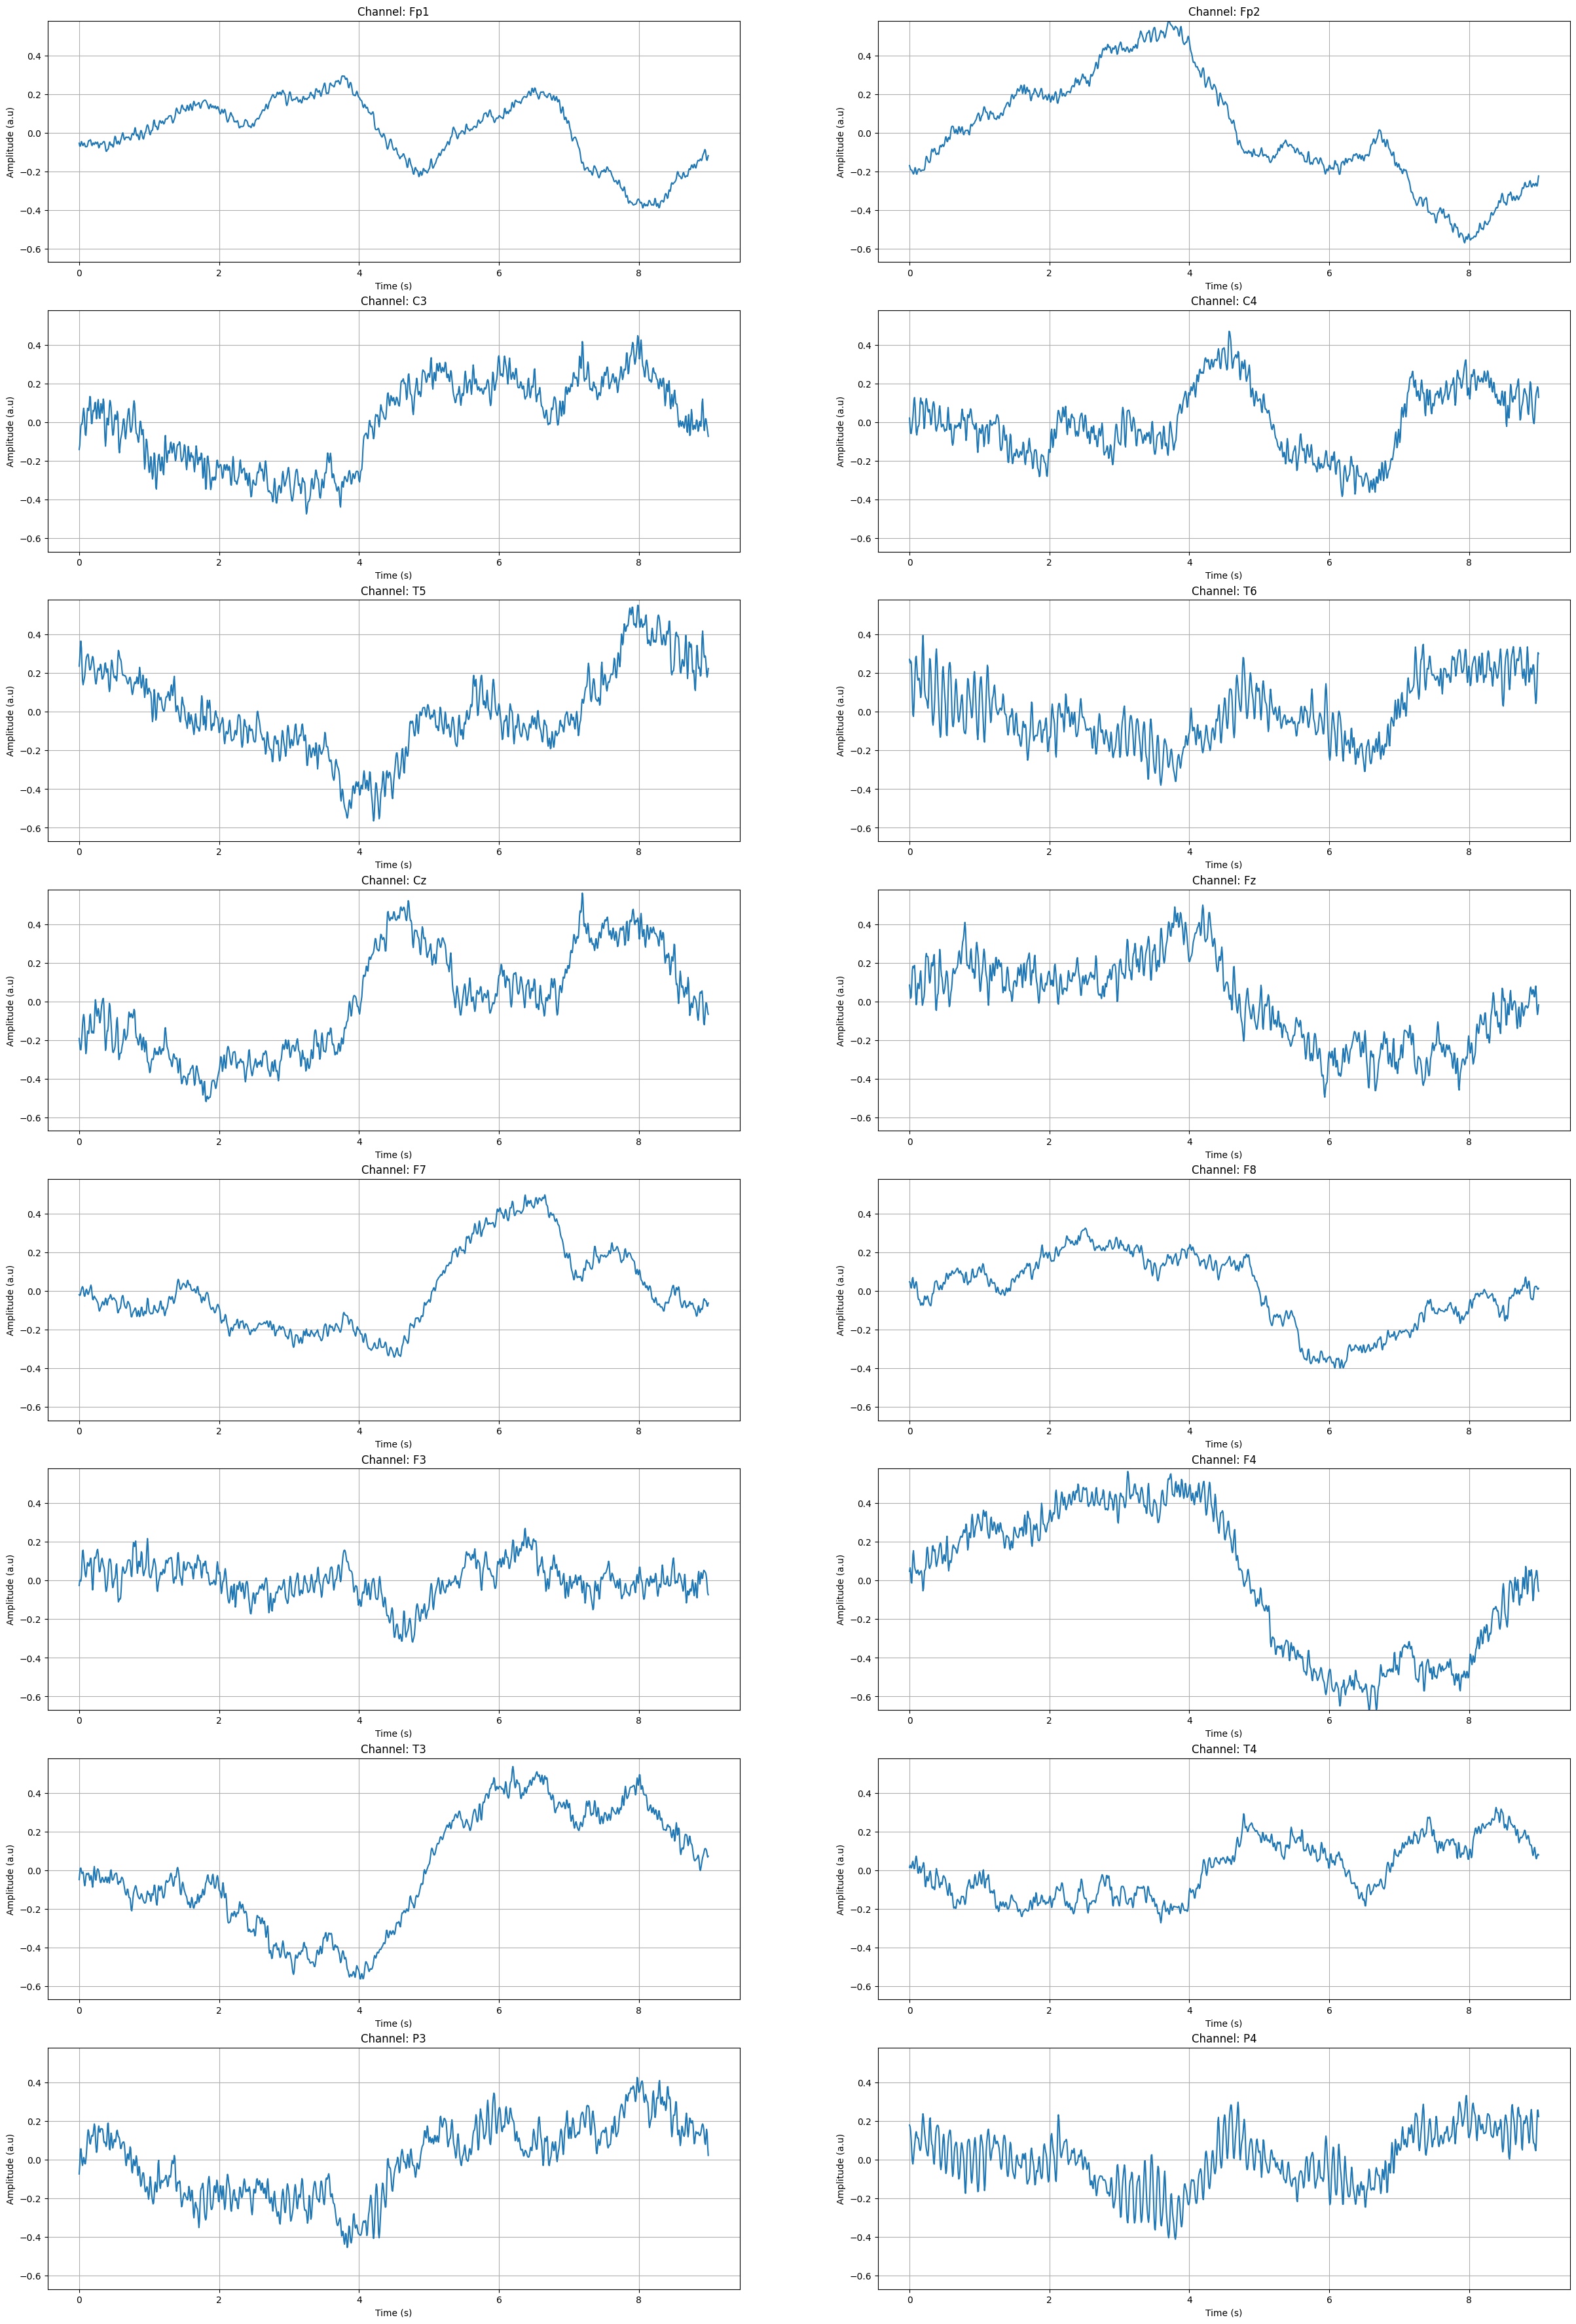

In [144]:
# plot_RMS_across_channels(RMS_index_epoch[0:90, :, :])
#plot_RMS_across_channels(EMG_index_epoch[60:90, :, :])

# plot_emg_mean_epoch_single_channels(EMG_list_index, RMS_list_index, key1 = 0, key2 = 0)
# plot_EMG_across_channels(X_train_left.mean(axis=0), freq = 250)
#plot_EMG_across_channels(EMG_thumb_epoch_con.mean(axis=0))

# plot_EEG_across_channels(RMS_index_epoch_con.mean(axis=0), freq = 125, sel_ch = sel_ch)
plot_EEG_across_channels(EEG_epoch_norm.mean(axis=0), freq = 125, sel_ch = None)

## Define hyperparameters

In [87]:
parameters = [sherpa.Continuous(name='learning_rate', range=[0.0001, 0.001], scale='log'),
              sherpa.Continuous(name='dropout', range=[0.1, 0.5]),
              sherpa.Ordinal(name='batch_size', range=[16, 32, 64]),
              sherpa.Discrete(name='num_hidden_units', range=[32, 64]),         # before 64
              sherpa.Choice(name='activation', range=['relu', 'elu']),
              sherpa.Ordinal(name='lstm_layers', range=[1])]

# Hyperparameter optimization algorithms
max_num_trials = 10
# algorithm = sherpa.algorithms.RandomSearch(max_num_trials = max_num_trials)
algorithm = sherpa.algorithms.GPyOpt(
        max_num_trials = max_num_trials,
        acquisition_type = 'EI',                     # Expected improvement
        num_initial_data_points = 6                 # Number of hyperparameter configurations before model learns
    )
# Study represents the hyperparameter optimization itself
study = sherpa.Study(
    parameters = parameters,
    algorithm = algorithm,
    lower_is_better = True,
    disable_dashboard = True
)
'''Additional hyperparameters
    Learning rate decay
    Number of dense nodes
    Number of filters
    Optimizer
'''

# records = []
# for trial in study:
#     acc = 7
#     row = {
#         "trial_id": trial.id,
#         **trial.parameters,
#         'accuracy' : acc
#         }
#     records.append(row)

'Additional hyperparameters\n    Learning rate decay\n    Number of dense nodes\n    Number of filters\n    Optimizer\n'

In [88]:
class ExperimentLogger:

    def __init__(self, save_path : str):
        self.save_path = save_path + '/SHERPA_results.pt'
        
        # Load existing file if present
        if os.path.exists(save_path):
            self.results = torch.load(save_path)
        else:
            self.results = {"trials": []}

    def log_trial(
        self,
        trial_id,
        hyperparams,
        best_epoch,
        train_loss,
        val_loss,
        val_acc,
        test_loss,
        test_acc,
        preds,
        labels):
        """
        Append one trial result.
        """

        trial_result = {
            "trial_id": trial_id,
            "hyperparameters": hyperparams,
            "best_epoch": best_epoch,
            "training_loss": train_loss,
            "validation_loss": val_loss,
            "validation_accuracy": val_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
            "predictions": preds,
            "labels": labels
        }

        self.results["trials"].append(trial_result)

        # Save immediately (safe against crashes)
        torch.save(self.results, self.save_path)

## Step 4: Train the LSTM Model

In [ ]:
log_name = 'BCI2a_subject_8_TESTER'
log_dir = os.path.abspath(os.path.join(os.getcwd(), f'loggings\{log_name}'))    # Path to log results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

logger = ExperimentLogger(save_path = log_dir)

split_ins = Manage3Split(seed = SEED)

num_index_trials = RMS_epoch_index.shape[0]
num_thumb_trials = RMS_epoch_thumb.shape[0]

train_i, val_i, test_i = split_ins.split_trials(num_index_trials)
train_t, val_t, test_t = split_ins.split_trials(num_thumb_trials)

X_train, y_train = split_ins.build_split(epoch_index = RMS_epoch_index,
                                         epoch_thumb = RMS_epoch_thumb,
                                         index_trials_indices = train_i,
                                         thumb_trials_indices = train_t,
                                         fs = RMS_FREQ)
X_val, y_val = split_ins.build_split(epoch_index = RMS_epoch_index,
                                         epoch_thumb = RMS_epoch_thumb,
                                         index_trials_indices = val_i,
                                         thumb_trials_indices = val_t,
                                         fs = RMS_FREQ)
X_test, y_test = split_ins.build_split(epoch_index = RMS_epoch_index,
                                         epoch_thumb = RMS_epoch_thumb,
                                         index_trials_indices = test_i,
                                         thumb_trials_indices = test_t,
                                         fs = RMS_FREQ)


#=======================#
# Multi fusion datasets #
#=======================#
# dataset_ins = MultiManageDataset(EEG_X, EMG_X, labels)
# train_eval_ins = FusionNet_train_eval()

#=================#
# Single datasets #
#=================#
train_eval_ins = SingleNet_train_eval()
print('Training dataset shapes:')
train_dataset_ins = SingleManageDataset(X_train, y_train)
print('Validation dataset shapes:')
val_dataset_ins = SingleManageDataset(X_val, y_val)
print('Testing dataset shapes:')
test_dataset_ins = SingleManageDataset(X_test, y_test)

#========================================================#
# THESE PARAMETERS ARE CHANCEABLE, DEPENDING ON THE TASK #
#========================================================#
DATA_CH = 3
NUM_CLASSES = 5
NUM_EPOCHS = 10
PATIENCE = 25                   # Early stopping patience - 25

# L_all = {}
# C_all = {}
# W_all = {}
# Y_all = {}

for trial in study:
    lr = trial.parameters['learning_rate']
    dropout = trial.parameters['dropout']       
    batch_size = trial.parameters['batch_size']
    num_hidden_units = trial.parameters['num_hidden_units']
    activation = trial.parameters['activation'] 
    lstm_layers = trial.parameters['lstm_layers']

    #=======================#
    # Multi fusion datasets #
    #=======================#
    # model = FusionNet(eeg_ch = 6, emg_ch = 3, hidden = num_hidden_units, lstm_layers = 1, num_classes = NUM_CLASSES, dropout = dropout, activation = activation)
    
    #=================#
    # Single datasets #
    #=================#
    model = SingleNet(data_ch = DATA_CH, hidden = num_hidden_units, lstm_layers = lstm_layers, num_classes = NUM_CLASSES, dropout = dropout, activation = activation)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    # DataLoaders (update batch_size)
    train_loader = DataLoader(train_dataset_ins, batch_size = batch_size, shuffle = True, pin_memory = pin_memory, num_workers = 0)
    val_loader = DataLoader(val_dataset_ins, batch_size = batch_size, shuffle = False, pin_memory = pin_memory, num_workers = 0)
    test_loader = DataLoader(test_dataset_ins, batch_size = batch_size, shuffle = False, pin_memory = pin_memory, num_workers = 0)

    best_train_loss = None
    best_val_loss = float("inf")
    best_val_acc = None

    best_epoch = 0
    best_state_dict = None
    early_stopping_counter = 0

    # Create log folder
    log_folder = os.path.join(log_dir, f"trial_{trial.id}")
    os.makedirs(log_folder, exist_ok=False)
    writer = SummaryWriter(os.path.join(log_folder, 'trial_{}_timestamp_{}'.format(trial.id, timestamp)))

    # L_epo = []
    # C_epo = []
    # W_epo = []
    # Y_epo = []

    for epoch in range(NUM_EPOCHS):

        # Train model
        avg_train_loss = train_eval_ins.train_one_epoch(model = model, train_loader = train_loader, criterion = criterion, optimizer = optimizer, device = device)

        # Validate model
        avg_vloss, vacc, _ = train_eval_ins.validaton_one_epoch(model = model, val_loader = val_loader, criterion = criterion, device = device)
        # L, C, W, Y = inspect

        # Collect all hidden states and labels for analysis
        # L_epo.append(torch.cat(L).numpy())
        # C_epo.append(torch.cat(C).numpy())
        # W_epo.append(torch.cat(W).numpy())
        # Y_epo.append(torch.cat(Y).numpy())

        # Tensor Board logging
        writer.add_scalars('Loss', { 'Training' : avg_train_loss, 'Validation' : avg_vloss }, epoch + 1)
        writer.add_scalars('Accuracy Validation', {'Validation' : vacc }, epoch + 1)
        writer.flush()

        study.add_observation(trial = trial,
                              iteration = epoch,
                              objective = avg_vloss)

        
        # Track best performance, and save the model's state
        if avg_vloss < best_val_loss:
            best_val_loss = avg_vloss
            best_epoch = epoch

            best_state_dict = deepcopy(model.state_dict())

            best_train_loss = avg_train_loss
            best_val_acc = vacc

            early_stopping_counter = 0

        else:
            early_stopping_counter += 1
            # print("Early stopping counter: {}/{}".format(early_stopping_counter, PATIENCE))

            if early_stopping_counter >= PATIENCE:
                # print("Early stopping triggered after {} epochs without improvement.".format(early_stopping_counter))
                break
        
        print(
            'Subject name | '
            f'Trial {trial.id}/{max_num_trials} | '
            f'Epoch {epoch+1}/{NUM_EPOCHS} | '
            f'Train {avg_train_loss:.4f} | '
            f'Val {avg_vloss:.4f} | '
            f'Acc {vacc:.2f} |',
            f'Early stopping {early_stopping_counter}',
            end='\r',
            flush=True
        )
    
    # L_all[trial.id] = L_epo
    # C_all[trial.id] = C_epo
    # W_all[trial.id] = W_epo
    # Y_all[trial.id] = Y_epo

    model.load_state_dict(best_state_dict)

    avg_test_loss, test_acc, predictions, labels = train_eval_ins.inference_one_epoch(model = model, test_loader = test_loader, criterion = criterion, device = device)

    torch.save({
        "model_state": best_state_dict,
        "model_args": {
            "data_ch": DATA_CH,
            "hidden": num_hidden_units,
            "lstm_layers": lstm_layers,
            "num_classes": NUM_CLASSES,
            "dropout": dropout,
            "activation": activation,}}, r'{}\model.pth'.format(log_folder))
    
    logger.log_trial(
        trial_id=trial.id,
        hyperparams={
            "lr": lr,
            "dropout": dropout,
            "batch_size": batch_size,
            "hidden": num_hidden_units,
            "activation": activation,
            "lstm_layers": lstm_layers
        },
        best_epoch = best_epoch,
        train_loss = best_train_loss,
        val_loss = best_val_loss,
        val_acc = best_val_acc,
        test_loss = avg_test_loss,
        test_acc = test_acc,
        preds = predictions,
        labels = labels)
    
    writer.close()
    # study.save(log_dir)
    study.finalize(trial, status = 'COMPLETED')

Training dataset shapes:
data shape: torch.Size([360, 375, 3])
labels shape: torch.Size([360])

Validation dataset shapes:
data shape: torch.Size([78, 375, 3])
labels shape: torch.Size([78])

Testing dataset shapes:
data shape: torch.Size([81, 375, 3])
labels shape: torch.Size([81])



In [91]:
sherpa_info_path = Path().resolve().parent / "models/loggings/BCI2a_subject_8_TESTER/SHERPA_results.pt"
if not os.path.exists(sherpa_info_path):
    raise FileExistsError(sherpa_info_path)
data = torch.load(sherpa_info_path, weights_only=False)

best = max(
    data["trials"],
    key=lambda x: x["test_accuracy"]
)

print('Best trial ID: ', best['trial_id'])
print('Training loss:' , best['training_loss'])
print('validation loss', best['validation_loss'])
print('Test accuracy: ', best["test_accuracy"])
print('Hyperparameter: ', best["hyperparameters"])

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(best['labels'], best['predictions'])
cm

Best trial ID:  9
Training loss: 0.49683224766150763
validation loss 0.45918232426047323
Test accuracy:  70.37037037037037
Hyperparameter:  {'lr': 0.001, 'dropout': 0.0, 'batch_size': 16, 'hidden': 57, 'activation': 'relu', 'lstm_layers': 1}


array([[11,  0,  3,  0,  0],
       [ 0, 12,  0,  2,  0],
       [ 8,  0,  5,  0,  0],
       [ 0, 11,  0,  2,  0],
       [ 0,  0,  0,  0, 27]], dtype=int64)

## Step 5: Visulize class distribution from hidden states

In [72]:
sel_trial_id = 42
npL = np.array(L_all[sel_trial_id])
npC = np.array(C_all[sel_trial_id])
npW = np.array(W_all[sel_trial_id])
npY = np.array(Y_all[sel_trial_id])
print(f'npL shape: {npL.shape}\n'
      f'npC shape: {npC.shape}\n'
      f'npW shape: {npW.shape}\n'
      f'npY shape: {npY.shape}')
# npH (epoch_idx, batches/trials, hidden_state)

npL shape: (70, 48, 3)
npC shape: (70, 48, 151)
npW shape: (70, 48, 17, 1)
npY shape: (70, 48)


### Plot hidden states distribution

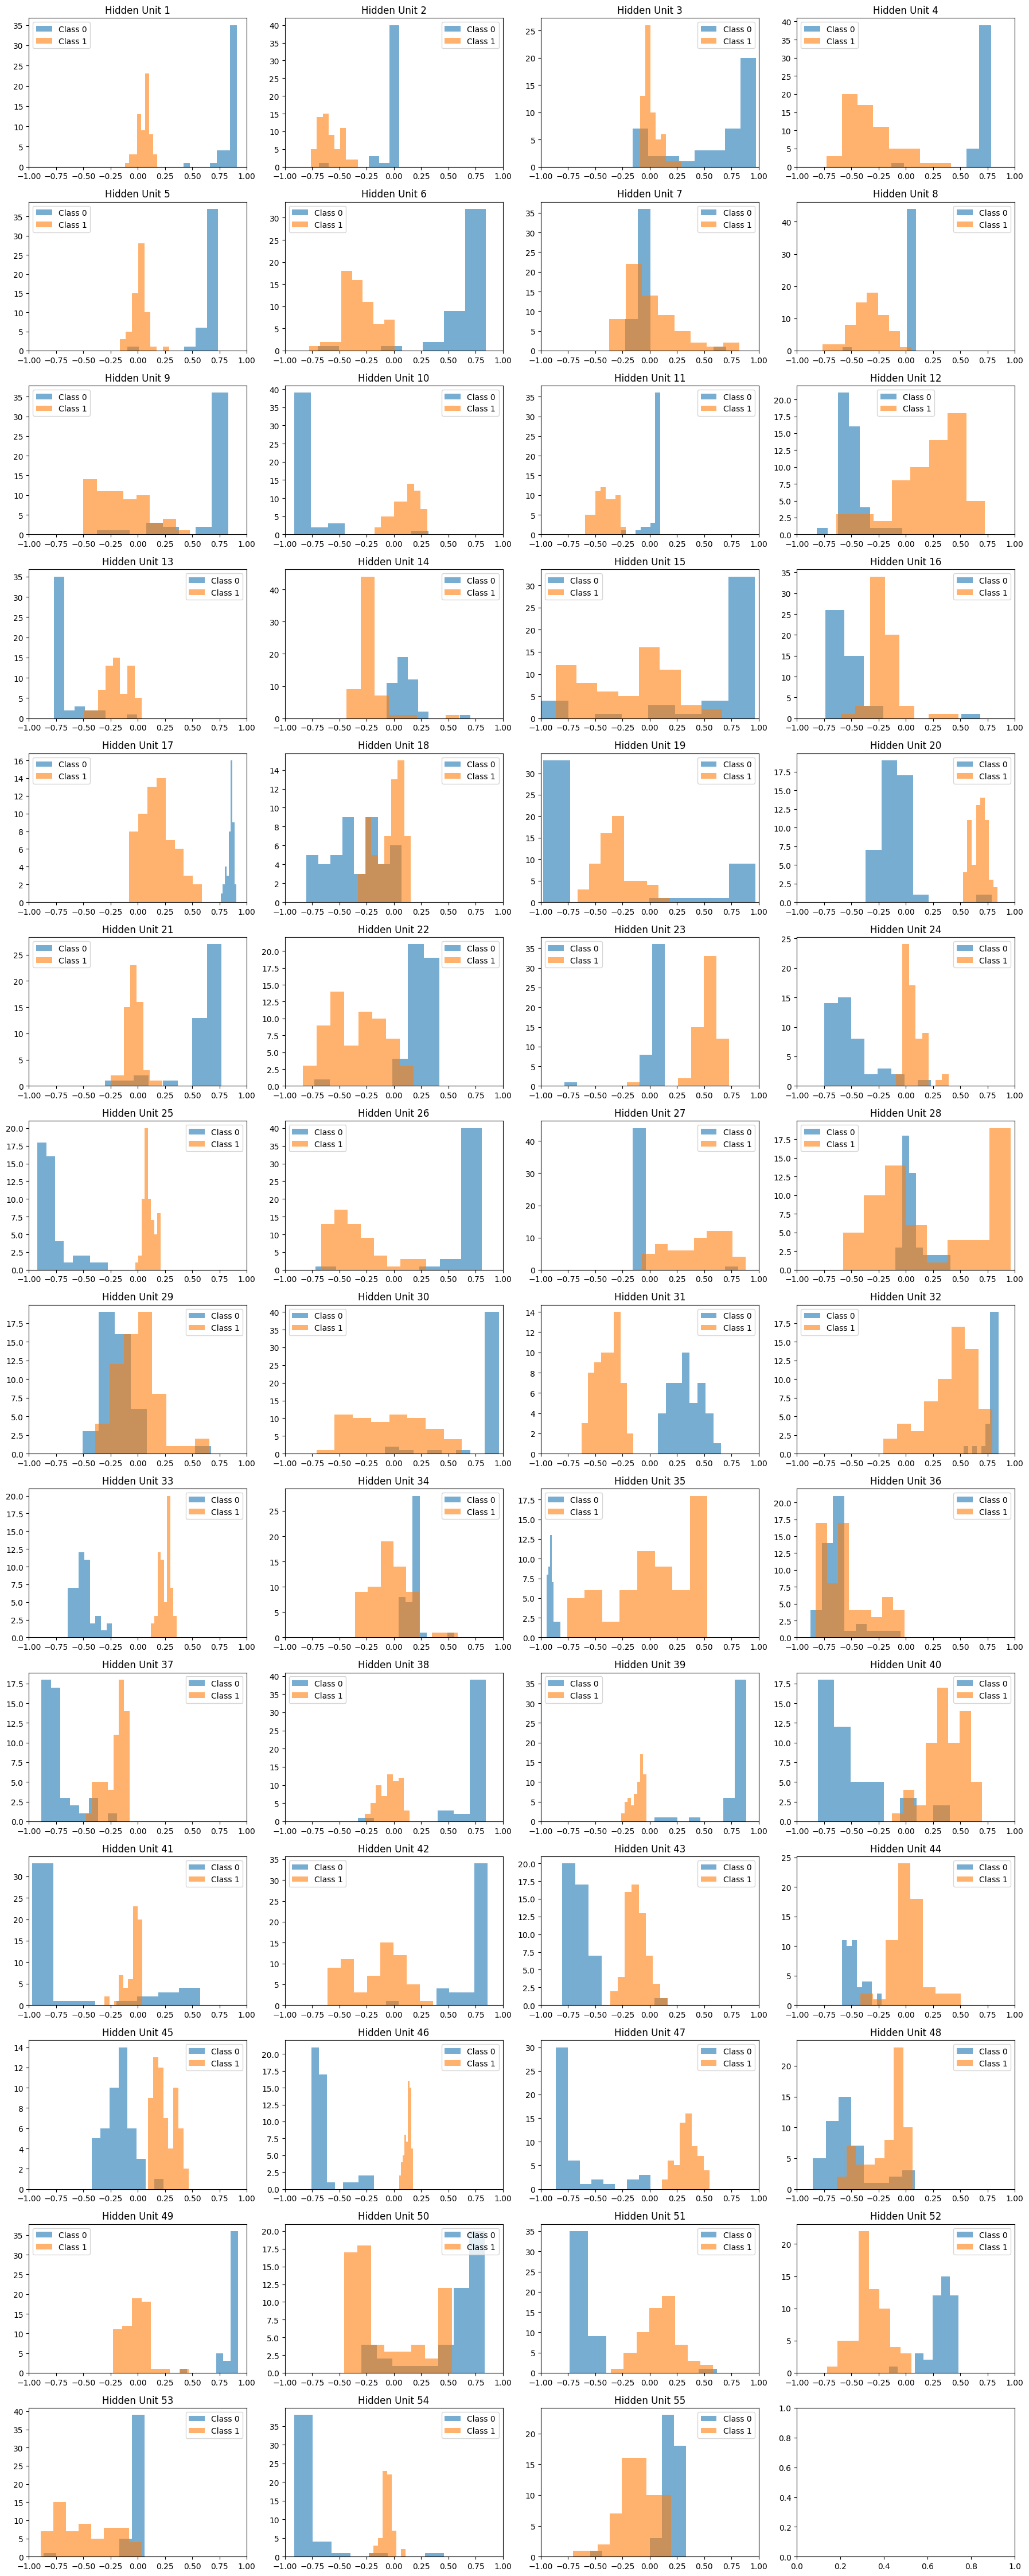

In [22]:
col_plots = 4
row_plots = int(np.ceil(npH.shape[2] / col_plots))

fig, ax = plt.subplots(row_plots, col_plots, figsize=(18, 45), squeeze=False)       # Add squeeze=False if displaying npL

epo = 143  # 8 Select which epoch to visualize
bins = int(np.ceil(np.sqrt(npH.shape[2])))      # Number of bins for histogram

x_max = np.max(npH)
x_min = np.min(npH)

for u in range(npH.shape[2]):
    # Boolean masks over batches
    mask0 = npY[epo, :] == 0
    mask1 = npY[epo, :] == 1

    # # Select hidden unit u for each class
    h0 = npH[epo, mask0, u]
    h1 = npH[epo, mask1, u]
    # print('h0 shape:', h0.shape, 'h1 shape:', h1.shape)
    # print("Class 0 std:", np.std(h0))
    # print("Class 1 std:", np.std(h1))

    r = u // col_plots
    c = u % col_plots
    ax[r, c].hist(h0, bins=bins, alpha=0.6, label="Class 0")
    ax[r, c].hist(h1, bins=bins, alpha=0.6, label="Class 1")
    ax[r, c].set_title(f'Hidden Unit {u+1}')
    ax[r, c].legend()
    ax[r, c].set_xlim(-1, 1)
    #ax[r, c].set_xlim([0, ])

plt.tight_layout()
plt.show()

### PCA

[0.99868417 0.0013158 ]


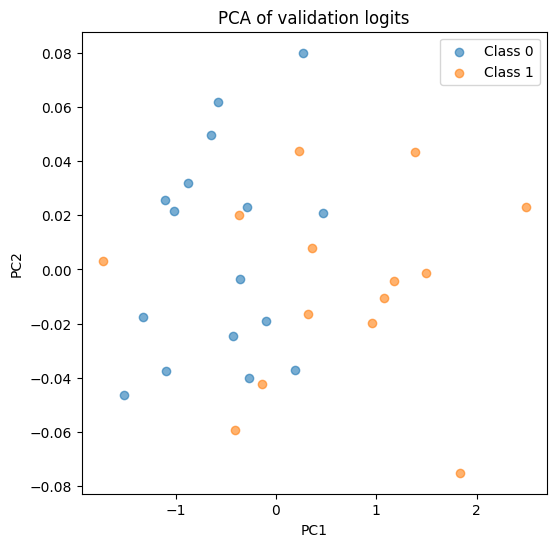

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

epo = 22
H_pca = pca.fit_transform(npL[epo, :, :])

print(pca.explained_variance_ratio_)

plt.figure(figsize=(6,6))
# npY[epo, :] == 0 - Takes all hidden features where class is 0
# H_pca[npY[epo, :]==0, 0] - Takes all PC1 values where class is 0

# 0 = index con. 
# 1 = index rel. 
# 2 = thumb con. 
# 3 = thumb rel. 
# 4 = rest
sel_class1 = 0
sel_class2 = 1
plt.scatter(H_pca[npY[epo, :] == sel_class1, 0], H_pca[npY[epo, :] == sel_class1, 1], alpha=0.6, label=f"Class {sel_class1}")
plt.scatter(H_pca[npY[epo, :] == sel_class2, 0], H_pca[npY[epo, :] == sel_class2, 1], alpha=0.6, label=f"Class {sel_class2}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of validation logits")
plt.show()

### T-SNE
Context: “The representation of the trial after the model has decided what time points matter”

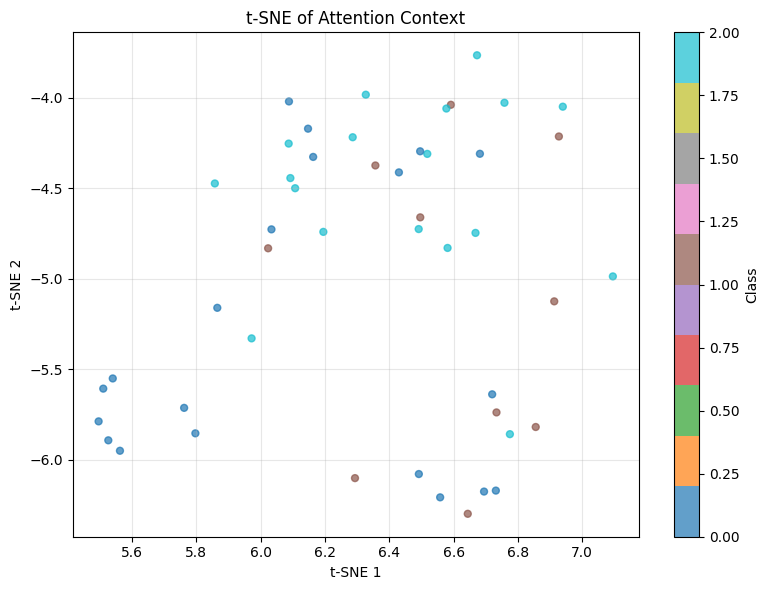

0.005738894


In [73]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

epo = 42

def plot_tsne_context(
    context,
    labels,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    title="t-SNE of Attention Context",
    figsize=(8, 6)
):
    """
    Plot t-SNE embedding of attention context vectors.

    Args:
        context (torch.Tensor or np.ndarray):
            Shape (n_samples, feature_dim)
        labels (torch.Tensor or np.ndarray):
            Shape (n_samples,)
        perplexity (int):
            t-SNE perplexity (typ. 5-50)
        n_iter (int):
            Number of optimization iterations
        random_state (int):
            Seed for reproducibility
        title (str):
            Plot title
        figsize (tuple):
            Figure size
    """

    # ---- detach safely ----
    if hasattr(context, "detach"):
        X = context.detach().cpu().numpy()
    else:
        X = np.asarray(context)

    if hasattr(labels, "detach"):
        y = labels.detach().cpu().numpy()
    else:
        y = np.asarray(labels)

    # ---- t-SNE ----
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        init="pca",
        learning_rate="auto",
        random_state=random_state
    )

    X_embedded = tsne.fit_transform(X)

    # ---- plot ----
    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=y,
        cmap="tab10",
        alpha=0.7,
        s=25
    )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(title)
    plt.colorbar(scatter, label="Class")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_tsne_context(context = npC[epo, :, :], labels = npY[epo, :], perplexity = 40, n_iter = 1000, random_state = 42)

score = silhouette_score(npC[epo, :, :], npY[epo, :])
print(score)

# ~0.5 → good separation
# ~0.2 → weak separation
# ~0 → no separation
# <0 → overlapping

### Attention weights
This tells you where in time the model is “looking”.

IndexError: index 88 is out of bounds for axis 1 with size 32

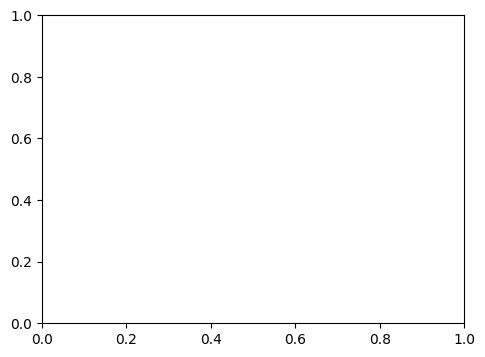

In [20]:
#===========================================#
# Compare Two Epochs from Different Classes #
#===========================================#

# Find one epoch from each class
class0_idx = np.where(npY[:,0] == 0)[0][0]
class1_idx = np.where(npY[:,0] == 1)[0][0]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(npW[class0_idx, epo].squeeze())
plt.title("Class 0 Attention")

plt.subplot(1,2,2)
plt.plot(npW[class1_idx, epo].squeeze())
plt.title("Class 1 Attention")

plt.tight_layout()
plt.show()


## Model interference

### Re-create the model exactly the same

In [76]:
model_path = Path().resolve() / 'loggings/SingleNet_EEG_3class_allFeatures_6chs/trial_42/model.pth'

checkpoint = torch.load(f = model_path, map_location = device)

model_interference = SingleNet(**checkpoint["model_args"])
model_interference.load_state_dict(checkpoint["model_state"])
model_interference.to(device)

SingleNet(
  (lstm): LSTM(90, 151, batch_first=True)
  (attension): Attension(
    (attn): Linear(in_features=151, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=151, out_features=75, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.07880848889435299, inplace=False)
    (3): Linear(in_features=75, out_features=3, bias=True)
  )
)

In [38]:
# inference_index_files = load_ins.find_flex_files(
#                 subjects = ['subject_0', 'subject_1'],
#                 modality = 'EMG',
#                 fingers = ['index'],
#                 prefix = 'flex'
# )
# inference_thumb_files = load_ins.find_flex_files(
#                 subjects = ['subject_0', 'subject_1'],
#                 modality = 'EMG',
#                 fingers = ['thumb'],
#                 prefix = 'flex'
# )

# EMG_index_inf, EMG_index_epoch_inf, EMG_index_epoch_mean_inf, total_epochs = load_ins.load_datasets_EMG(
#     path_to_data_files = inference_index_files,
#     preprocessing_func = EMG_ins.preprocessing_routine_rms,
#     sample_window = RMS_SAMPLING_WINDOW,
#     window_stepsize = RMS_WINDOW_STEPSIZE
# )

# EMG_thumb_inf, EMG_thumb_epoch_inf, EMG_thumb_epoch_mean_inf, total_epochs = load_ins.load_datasets_EMG(
#     path_to_data_files = inference_thumb_files,
#     preprocessing_func = EMG_ins.preprocessing_routine_rms,
#     sample_window = RMS_SAMPLING_WINDOW,
#     window_stepsize = RMS_WINDOW_STEPSIZE
# )

#================#
# RELOAD DATASET #
#================#
EMG_index_epoch_inf = EMG_index_epoch.copy()
EMG_thumb_epoch_inf = EMG_thumb_epoch.copy()

In [27]:
X_INF, labels_inf = None, None
#X_INF = np.concatenate((EMG_index_epoch_inf, EMG_thumb_epoch_inf))
#labels_inf = np.concatenate( (np.zeros(EMG_index_epoch_inf.shape[0]), np.ones(EMG_thumb_epoch_inf.shape[0])))
X_INF = X_EEG.copy()
labels_inf = labels_EEG.copy()

dataset_ins = SingleManageDataset(data = X_INF, labels = labels_inf)
rng = dataset_ins.get_rng_generator()

indices = rng.permutation(len(labels_inf))

inf_dataset = Subset(dataset_ins, indices)

inf_loader = DataLoader(inf_dataset, batch_size=32, shuffle=True, pin_memory=pin_memory, num_workers=0)

data shape: torch.Size([146, 17, 240])
labels shape: torch.Size([146])


In [77]:
inf_loader = test_loader

### Evaluation loop

In [78]:
from sklearn.metrics import confusion_matrix

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in inf_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits, _, _ = model_interference(inputs)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

[[12  6  2]
 [ 1  4  5]
 [ 0  4 14]]
[[0.6        0.3        0.1       ]
 [0.1        0.4        0.5       ]
 [0.         0.22222222 0.77777778]]
Test accuracy: 0.6250


                    Predicted
               | Index  |  Thumb
              -----------------------
True  Index    |   TN   |   FP
True  Thumb    |   FN   |   TP

TN: Predicted index correct
FP: Predicted thumb, but was index
FN: Predicted index, but was thumb
TP: Predicted thumb correct